In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import textwrap
import re
import os
import nltk
from nltk import sent_tokenize
from nltk import word_tokenize
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, roc_auc_score
from scipy.sparse import hstack
from sklearn import tree
import graphviz
from sklearn.model_selection import GridSearchCV

In [3]:
df = pd.read_csv("/Users/kayla/CORAAL_text_ml_dataset.csv")
df.head()

,CORAAL.File,region,speaker_id,gender,age,age_group,socioeconomic,education,occupation,interview_year,...,word_count,year_of_birth,mother_birthplace,mother_state,mother_occupation,father_birthplace,father_state,father_occupation,transcript,total_lines
0,ATL_se0_ag2_f_01_1,ATL,ATL_se0_ag2_f_01,Female,32,30 to 50,0,Some College,Entrepreneur,2017,...,6881,1984,St. Vincent and the Grenadines,St. Vincent and the Grenadines,Data entry specialist,St. Vincent and the Grenadines,St. Vincent and the Grenadines,Designer,Okay. (pause 1.03) How's it going? (pause 0.24...,1659
1,ATL_se0_ag2_m_01_1,ATL,ATL_se0_ag2_m_01,Male,40,30 to 50,0,Some College,Homemaker,2017,...,7166,1976,South Carolina,SC,Home business,"""Augusta, GA""",GA,Movie electrician,"Okay, (pause 1.00) this is, um, another interv...",1800
2,ATL_se0_ag2_f_02_1,ATL,ATL_se0_ag2_f_02,Female,36,30 to 50,0,College,"""Nurse, Entrepreneur""",2017,...,5252,1980,"""Arlington, GA""",GA,Retired accountant; Real estate agent,"""St. Petersburg, FL""",FL,Retired Police Officer,Hey what's going on? (pause 0.63) I'm here wit...,1724
3,ATL_se0_ag1_m_01_1,ATL,ATL_se0_ag1_m_01,Male,24,-29,0,Some College,Graphic designer; Creator,2017,...,7223,1993,"""Atlanta, GA""",GA,Property manager,"""Little Rock, Arkansas""",AR,Ironworker,"Yo, um, (pause 1.03) This is /RD-NAME-2/, (pau...",1899
4,ATL_se0_ag1_f_01_1,ATL,ATL_se0_ag1_f_01,Female,22,-29,0,High School,Cashier,2017,...,4586,1995,Florida,FL,Nursing,"""Atlanta, GA""",GA,Construction,"They talking about, don't send him to his dadd...",1233


In [4]:
df.shape

(303, 21)

# Text Processing

In [5]:
# create function to systematically clean transcipt texts
def clean_transcript(text): 
    """ 
    Removes pauses, tags, redacted names, extra whitespace.
    """ 
    # Remove (pause X.XX) annotations 
    text = re.sub(r'\(pause [0-9.]+\)', '', text) 
    # Remove leading numbers with closing parenthesis, e.g., 0.28)
    text = re.sub(r'^\d+(\.\d+)?\)\s*', '', text)
    # Remove tags like <ts>, <laugh>, etc. 
    text = re.sub(r'<[^>]+>', '', text) 
    # Remove redacted speaker names /RD-NAME-3/ 
    text = re.sub(r'/RD-NAME-\d+/', '', text) 
    # Remove /.../ 
    text = re.sub(r'/\w+/', '', text) 
    # Remove redacted places 
    text = re.sub(r'/\w+-\w+-\w+/', '', text) 
    # Replace hyphenated interrupted words like 'interviewi- /iewing/' with a space 
    text = re.sub(r'-\s*/[^/]+/', ' ', text) 
    # Remove square-bracketed annotations [Mm-hm.], [Okay.], etc.
    text = re.sub(r'\[[^\]]+\]', '', text)
    # Remove extra whitespace and newlines 
    text = re.sub(r'\s+', ' ', text).strip() 
    # remove []
    text = re.sub("\[]", "", text)
    # remove "/""
    text = re.sub("\/", "", text)
    # remove "-"
    text = re.sub("\-", "", text)
    # remove extra spaces
    text = re.sub("  ", " ", text)
    # remove (laughing), (whisper), etc
    text = re.sub("\(\w+\)", "", text)

    
    return text

In [6]:
# check it works properly
sample_text = clean_transcript(df["transcript"][0])
print(textwrap.fill(sample_text, width= 100))

Okay. How's it going? Of course my name is . I'm the guy that's gonna be interviewi today. Can I
start by your name? What's your name? My name is . Okay, cool, cool. Um, with a name like that, I'm
assuming you're female? But y for the record, are you female? I'm a female. Okay your ethnicity? I
am two it's two and more r races, two or more races. Which is? I'm And then I have a little bit of
Spaniard. Okay, cool cool, don't mind me, I will want you to kind of open up and give me some long
winded type answers Um, what year were you born? Nineteen eightyfour Okay. of April. Nineteen
eightyfour of April. What what sign would that make you? I'm a Aries, very feisty. Okay. That's
cool, that's what's up, we can We can possibly talk about that in a little bit, let me see what else
let me just go down the checklist right quick. What's your hometown? Brooklyn, New York. Okay,
Brooklyn, New York. Stand by. Stand up. to say. I'm a little nervous. , don't be nervous.  okay, um,
how many years have

In [7]:
# apply to entire transcript column
df['transcript'] = df['transcript'].apply(clean_transcript)

In [8]:
# split text into chunks of 200 words each
chunk_size = 200
rows = []

for _, row in df.iterrows():
    words = str(row["transcript"]).split()
    
    # Split transcript into chunks
    for i in range(0, len(words), chunk_size):
        chunk_words = words[i:i + chunk_size]
        chunk_text = " ".join(chunk_words)
        
        new_row = row.copy()
        new_row["transcript"] = chunk_text
        new_row["chunk_id"] = i // chunk_size
        
        rows.append(new_row)

df = pd.DataFrame(rows)
df = df.reset_index(drop=True)
df.head()

,CORAAL.File,region,speaker_id,gender,age,age_group,socioeconomic,education,occupation,interview_year,...,year_of_birth,mother_birthplace,mother_state,mother_occupation,father_birthplace,father_state,father_occupation,transcript,total_lines,chunk_id
0,ATL_se0_ag2_f_01_1,ATL,ATL_se0_ag2_f_01,Female,32,30 to 50,0,Some College,Entrepreneur,2017,...,1984,St. Vincent and the Grenadines,St. Vincent and the Grenadines,Data entry specialist,St. Vincent and the Grenadines,St. Vincent and the Grenadines,Designer,Okay. How's it going? Of course my name is . I...,1659,0
1,ATL_se0_ag2_f_01_1,ATL,ATL_se0_ag2_f_01,Female,32,30 to 50,0,Some College,Entrepreneur,2017,...,1984,St. Vincent and the Grenadines,St. Vincent and the Grenadines,Data entry specialist,St. Vincent and the Grenadines,St. Vincent and the Grenadines,Designer,Georgia? Just for five years. Okay. Would you ...,1659,1
2,ATL_se0_ag2_f_01_1,ATL,ATL_se0_ag2_f_01,Female,32,30 to 50,0,Some College,Entrepreneur,2017,...,1984,St. Vincent and the Grenadines,St. Vincent and the Grenadines,Data entry specialist,St. Vincent and the Grenadines,St. Vincent and the Grenadines,Designer,"is where I get the Spaniards from. And um, Yea...",1659,2
3,ATL_se0_ag2_f_01_1,ATL,ATL_se0_ag2_f_01,Female,32,30 to 50,0,Some College,Entrepreneur,2017,...,1984,St. Vincent and the Grenadines,St. Vincent and the Grenadines,Data entry specialist,St. Vincent and the Grenadines,St. Vincent and the Grenadines,Designer,for cartoons and stuff like that. So there's a...,1659,3
4,ATL_se0_ag2_f_01_1,ATL,ATL_se0_ag2_f_01,Female,32,30 to 50,0,Some College,Entrepreneur,2017,...,1984,St. Vincent and the Grenadines,St. Vincent and the Grenadines,Data entry specialist,St. Vincent and the Grenadines,St. Vincent and the Grenadines,Designer,and I tell you about your mistakes. All while ...,1659,4


In [9]:
# see one chunk
print(textwrap.fill(df["transcript"][0], width= 100))

Okay. How's it going? Of course my name is . I'm the guy that's gonna be interviewi today. Can I
start by your name? What's your name? My name is . Okay, cool, cool. Um, with a name like that, I'm
assuming you're female? But y for the record, are you female? I'm a female. Okay your ethnicity? I
am two it's two and more r races, two or more races. Which is? I'm And then I have a little bit of
Spaniard. Okay, cool cool, don't mind me, I will want you to kind of open up and give me some long
winded type answers Um, what year were you born? Nineteen eightyfour Okay. of April. Nineteen
eightyfour of April. What what sign would that make you? I'm a Aries, very feisty. Okay. That's
cool, that's what's up, we can We can possibly talk about that in a little bit, let me see what else
let me just go down the checklist right quick. What's your hometown? Brooklyn, New York. Okay,
Brooklyn, New York. Stand by. Stand up. to say. I'm a little nervous. , don't be nervous. okay, um,
how many years have 

In [10]:
df.shape

(8064, 22)

In [11]:
# Drop columns that are no longer needed (transcript_length, total_lines, word_count correspond to original transcripts before chunking/processing)
df = df.drop(columns=["transcript_length", "total_lines", "word_count", "CORAAL.File", "speaker_id"])

df.head()

,region,gender,age,age_group,socioeconomic,education,occupation,interview_year,year_of_birth,mother_birthplace,mother_state,mother_occupation,father_birthplace,father_state,father_occupation,transcript,chunk_id
0,ATL,Female,32,30 to 50,0,Some College,Entrepreneur,2017,1984,St. Vincent and the Grenadines,St. Vincent and the Grenadines,Data entry specialist,St. Vincent and the Grenadines,St. Vincent and the Grenadines,Designer,Okay. How's it going? Of course my name is . I...,0
1,ATL,Female,32,30 to 50,0,Some College,Entrepreneur,2017,1984,St. Vincent and the Grenadines,St. Vincent and the Grenadines,Data entry specialist,St. Vincent and the Grenadines,St. Vincent and the Grenadines,Designer,Georgia? Just for five years. Okay. Would you ...,1
2,ATL,Female,32,30 to 50,0,Some College,Entrepreneur,2017,1984,St. Vincent and the Grenadines,St. Vincent and the Grenadines,Data entry specialist,St. Vincent and the Grenadines,St. Vincent and the Grenadines,Designer,"is where I get the Spaniards from. And um, Yea...",2
3,ATL,Female,32,30 to 50,0,Some College,Entrepreneur,2017,1984,St. Vincent and the Grenadines,St. Vincent and the Grenadines,Data entry specialist,St. Vincent and the Grenadines,St. Vincent and the Grenadines,Designer,for cartoons and stuff like that. So there's a...,3
4,ATL,Female,32,30 to 50,0,Some College,Entrepreneur,2017,1984,St. Vincent and the Grenadines,St. Vincent and the Grenadines,Data entry specialist,St. Vincent and the Grenadines,St. Vincent and the Grenadines,Designer,and I tell you about your mistakes. All while ...,4


In [12]:
df.columns

Index(['region', 'gender', 'age', 'age_group', 'socioeconomic', 'education',
       'occupation', 'interview_year', 'year_of_birth', 'mother_birthplace',
       'mother_state', 'mother_occupation', 'father_birthplace',
       'father_state', 'father_occupation', 'transcript', 'chunk_id'],
      dtype='object')

In [13]:
# add chunk word count to view chunk lengths
df["chunk_word_count"] = df["transcript"].str.split().apply(len)

# Exploratory Data Analysis

In [14]:
df.head()

,region,gender,age,age_group,socioeconomic,education,occupation,interview_year,year_of_birth,mother_birthplace,mother_state,mother_occupation,father_birthplace,father_state,father_occupation,transcript,chunk_id,chunk_word_count
0,ATL,Female,32,30 to 50,0,Some College,Entrepreneur,2017,1984,St. Vincent and the Grenadines,St. Vincent and the Grenadines,Data entry specialist,St. Vincent and the Grenadines,St. Vincent and the Grenadines,Designer,Okay. How's it going? Of course my name is . I...,0,200
1,ATL,Female,32,30 to 50,0,Some College,Entrepreneur,2017,1984,St. Vincent and the Grenadines,St. Vincent and the Grenadines,Data entry specialist,St. Vincent and the Grenadines,St. Vincent and the Grenadines,Designer,Georgia? Just for five years. Okay. Would you ...,1,200
2,ATL,Female,32,30 to 50,0,Some College,Entrepreneur,2017,1984,St. Vincent and the Grenadines,St. Vincent and the Grenadines,Data entry specialist,St. Vincent and the Grenadines,St. Vincent and the Grenadines,Designer,"is where I get the Spaniards from. And um, Yea...",2,200
3,ATL,Female,32,30 to 50,0,Some College,Entrepreneur,2017,1984,St. Vincent and the Grenadines,St. Vincent and the Grenadines,Data entry specialist,St. Vincent and the Grenadines,St. Vincent and the Grenadines,Designer,for cartoons and stuff like that. So there's a...,3,200
4,ATL,Female,32,30 to 50,0,Some College,Entrepreneur,2017,1984,St. Vincent and the Grenadines,St. Vincent and the Grenadines,Data entry specialist,St. Vincent and the Grenadines,St. Vincent and the Grenadines,Designer,and I tell you about your mistakes. All while ...,4,200


In [15]:
df.columns

Index(['region', 'gender', 'age', 'age_group', 'socioeconomic', 'education',
       'occupation', 'interview_year', 'year_of_birth', 'mother_birthplace',
       'mother_state', 'mother_occupation', 'father_birthplace',
       'father_state', 'father_occupation', 'transcript', 'chunk_id',
       'chunk_word_count'],
      dtype='object')

In [16]:
# how many duplicated rows?
duplicates = df.duplicated()
print(duplicates.sum())

238


In [17]:
# drop duplicates to avoid redundancy
df = df.drop_duplicates()
df.shape

(7826, 18)

In [18]:
# check missing data
missing_counts = df.isna().sum()
missing_counts

region               0
gender               0
age                  0
age_group            0
socioeconomic        0
education            0
occupation           0
interview_year       0
year_of_birth        0
mother_birthplace    0
mother_state         0
mother_occupation    0
father_birthplace    0
father_state         0
father_occupation    0
transcript           0
chunk_id             0
chunk_word_count     0
dtype: int64

In [19]:
# check data types across columns
df.dtypes

region               object
gender               object
age                   int64
age_group            object
socioeconomic         int64
education            object
occupation           object
interview_year        int64
year_of_birth         int64
mother_birthplace    object
mother_state         object
mother_occupation    object
father_birthplace    object
father_state         object
father_occupation    object
transcript           object
chunk_id              int64
chunk_word_count      int64
dtype: object

In [20]:
# checking value counts for each predictive column (excluding chunk text + id)
cols_to_check = df.columns.drop(["transcript", "chunk_id"])
for col in cols_to_check:
    print(df[col].value_counts())
    print("----------------------------------------")

region
DCB    2462
DCA    1489
DTA    1075
ROC     859
PRV     793
VLD     418
LES     384
ATL     346
Name: count, dtype: int64
----------------------------------------
gender
Female    3918
Male      3908
Name: count, dtype: int64
----------------------------------------
age
25    444
31    330
32    328
61    322
24    277
     ... 
71     29
67     28
13     27
9      21
77      7
Name: count, Length: 62, dtype: int64
----------------------------------------
age_group
30 to 50    2310
51+         1848
-19         1617
20 to 29    1337
-29          714
Name: count, dtype: int64
----------------------------------------
socioeconomic
0    2800
2    1935
1    1616
3    1475
Name: count, dtype: int64
----------------------------------------
education
High School               2070
Some College              1580
College                   1404
Student_ms                 638
Student_hs                 592
Graduate School            590
Some High School           295
Some Middle School     

Age Group needs adjusting. Here is the current encoding from the data source:

age_group encoding: 
- DCA, DCB, DTA, LES, VLD: AG1 = -19, AG2 = 20 to 29, AG3 = 30 to 50, AG4 = 51+
- PRV and CORAAL:ROC (three age groups): AG1 = -29, AG2 = 30 to 50, AG3 = 51+
- ATL (two age groups): AG1 = -29, AG2 = 30 to 50
- Notes: LES and VLD follow the Age Groups from DCA and DCB but only contain speakers from AG2, AG3, and AG4.

In [21]:
# changing age_group to 4 consistent groups ("youngest" = 0, 20-29 = 1, 30-50 = 2, 51+ = 3)

age_mapping = {
    "-19": 0,
    "-29": 0,
    "20 to 29": 1,
    "30 to 50": 2,
    "51+": 3
}
df["age_group"] = df["age_group"].map(age_mapping)
df["age_group"].value_counts()

age_group
0    2331
2    2310
3    1848
1    1337
Name: count, dtype: int64

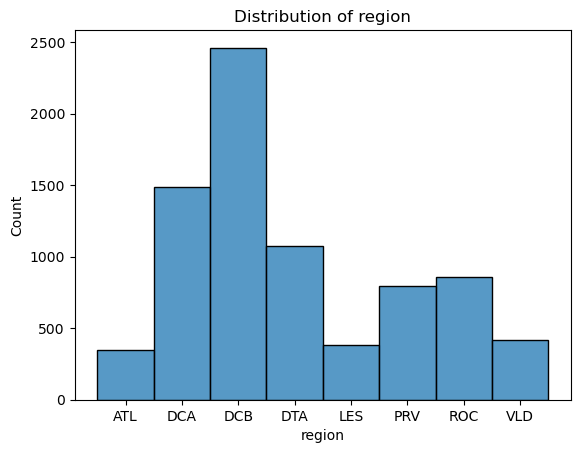

In [22]:
# target variable distribution
sns.histplot(df["region"], bins=20)
plt.title(f"Distribution of region")
plt.show()

**Regions Info**
- ATL = Atlanta, GA (interview took place in either 2017 or 2018)
- DCA = Washington, DC (interview took place in either 1968 or 1969)
- DCB = Washington, DC (interview took place in either 2015 or 2016)
- DTA = Detroit, MI (interview took place in 1966)
- LES = Lower East Side, NY (interview took place in either 2008 or 2009)
- PRV = Princeville, NC (interview took place in either 2003 or 2004)
- ROC = Rochester, NY (interview took place in either 2016 or 2017)
- VLD = Valdosta, GA (interview took place in either 2017 or 2019)

# EDA - Categorical Data Processing

In [23]:
df.head()

,region,gender,age,age_group,socioeconomic,education,occupation,interview_year,year_of_birth,mother_birthplace,mother_state,mother_occupation,father_birthplace,father_state,father_occupation,transcript,chunk_id,chunk_word_count
0,ATL,Female,32,2,0,Some College,Entrepreneur,2017,1984,St. Vincent and the Grenadines,St. Vincent and the Grenadines,Data entry specialist,St. Vincent and the Grenadines,St. Vincent and the Grenadines,Designer,Okay. How's it going? Of course my name is . I...,0,200
1,ATL,Female,32,2,0,Some College,Entrepreneur,2017,1984,St. Vincent and the Grenadines,St. Vincent and the Grenadines,Data entry specialist,St. Vincent and the Grenadines,St. Vincent and the Grenadines,Designer,Georgia? Just for five years. Okay. Would you ...,1,200
2,ATL,Female,32,2,0,Some College,Entrepreneur,2017,1984,St. Vincent and the Grenadines,St. Vincent and the Grenadines,Data entry specialist,St. Vincent and the Grenadines,St. Vincent and the Grenadines,Designer,"is where I get the Spaniards from. And um, Yea...",2,200
3,ATL,Female,32,2,0,Some College,Entrepreneur,2017,1984,St. Vincent and the Grenadines,St. Vincent and the Grenadines,Data entry specialist,St. Vincent and the Grenadines,St. Vincent and the Grenadines,Designer,for cartoons and stuff like that. So there's a...,3,200
4,ATL,Female,32,2,0,Some College,Entrepreneur,2017,1984,St. Vincent and the Grenadines,St. Vincent and the Grenadines,Data entry specialist,St. Vincent and the Grenadines,St. Vincent and the Grenadines,Designer,and I tell you about your mistakes. All while ...,4,200


In [24]:
# pull out categorical columns for processing
cat_cols = ["education", "age_group", "gender", "socioeconomic", "occupation", "mother_birthplace", "mother_state",
       "mother_occupation", "father_birthplace", "father_state", "father_occupation"]

df[cat_cols]

,education,age_group,gender,socioeconomic,occupation,mother_birthplace,mother_state,mother_occupation,father_birthplace,father_state,father_occupation
0,Some College,2,Female,0,Entrepreneur,St. Vincent and the Grenadines,St. Vincent and the Grenadines,Data entry specialist,St. Vincent and the Grenadines,St. Vincent and the Grenadines,Designer
1,Some College,2,Female,0,Entrepreneur,St. Vincent and the Grenadines,St. Vincent and the Grenadines,Data entry specialist,St. Vincent and the Grenadines,St. Vincent and the Grenadines,Designer
2,Some College,2,Female,0,Entrepreneur,St. Vincent and the Grenadines,St. Vincent and the Grenadines,Data entry specialist,St. Vincent and the Grenadines,St. Vincent and the Grenadines,Designer
3,Some College,2,Female,0,Entrepreneur,St. Vincent and the Grenadines,St. Vincent and the Grenadines,Data entry specialist,St. Vincent and the Grenadines,St. Vincent and the Grenadines,Designer
4,Some College,2,Female,0,Entrepreneur,St. Vincent and the Grenadines,St. Vincent and the Grenadines,Data entry specialist,St. Vincent and the Grenadines,St. Vincent and the Grenadines,Designer
...,...,...,...,...,...,...,...,...,...,...,...
8059,Some High School,3,Male,0,Disabled/Plumber,"Valdosta, GA",GA,Housewife,"Valdosta, GA",GA,Construction
8060,Some High School,3,Male,0,Disabled/Plumber,"Valdosta, GA",GA,Housewife,"Valdosta, GA",GA,Construction
8061,Some High School,3,Male,0,Disabled/Plumber,"Valdosta, GA",GA,Housewife,"Valdosta, GA",GA,Construction
8062,Some High School,3,Male,0,Disabled/Plumber,"Valdosta, GA",GA,Housewife,"Valdosta, GA",GA,Construction


In [25]:
# outlier detection (viewing value counts to identify rare categories)

for col in cat_cols:
    print(f"{col}: ------------------------------------------------------")
    print(df[col].value_counts().values)

education: ------------------------------------------------------
[2070 1580 1404  638  592  590  295  166  127  124   63   63   60   54]
age_group: ------------------------------------------------------
[2331 2310 1848 1337]
gender: ------------------------------------------------------
[3918 3908]
socioeconomic: ------------------------------------------------------
[2800 1935 1616 1475]
occupation: ------------------------------------------------------
[1479  303  206  202  163  154  139  136  128  104   99   98   98   92
   76   74   72   72   67   62   61   59   59   58   57   55   55   53
   52   52   52   51   51   50   50   48   48   48   48   48   47   47
   46   46   46   46   45   45   44   44   44   43   43   43   42   42
   41   40   40   39   39   39   39   38   38   37   37   37   37   37
   37   37   37   36   36   35   35   35   35   35   35   34   34   34
   34   33   32   32   32   31   30   30   30   30   30   28   28   28
   28   27   27   27   26   26   26   25   

Comment: Rather than removing smaller categories, we will merge them into larger ones so that data is not lost (dimension reduction).

**Category Merging**

In [26]:
# dropping mother_birthplace, father_birthplace, mother_state, father_state to avoid collinearity
# (these columns may be weighted too heavily in predicting speaker's region)

df = df.drop(columns=["mother_birthplace", "father_birthplace", "mother_state", "father_state"])

In [27]:
# creating list of all occupations in "occupation" to view distribution
occs = df["occupation"].unique().tolist()
for occ in occs:
     print(occ)

Entrepreneur
Homemaker
"Nurse, Entrepreneur"
Graphic designer; Creator
Cashier
Security Guard
Producer
Musician
Hustler
Teacher
Artist
DJ/Radio Host
Student
Student/Shoe Shiner
Case Worker
Unemployed
PBX Operator
Manpower
Secretary
Army Sargent
Automatic Coil Operator
Porter
Store Clerk
Unknown
Head of House
Grocery Clerk
Taxi Driver
Truck Driver
Baby Sitter
Waiter
Pupil Personal Aide
Executive Secretary
Soldier
Sales Clerk
Mail Handler
Coordinator of Activities
Maitenance Man
Psychology Professor
Supplier Clerk
Fire Battalion Chief
Store Owner
Summer worker, Administrative Assistant at Boys and Girls Club
Membership Coordinator
Summer Employee
Intern as a Photographer at Dept of Energy 
Program Coordinator for inspection company
Volunteer Coordinator and Administrative Assistant
Foodservice Worker
Student, Mother
Program Aide
Self-employed
Temp Agent, Customer Service
Postal Worker
Telecommunications, Private Chef
Custodian
Community Health Worker
Retired
Special Investigator
Lead Leg

Comment: Due to a wide range of occupations, they will be sorted into general groups (based on my own interpretation).

In [28]:
# merging occupations

occupation_mapping = {
    # Professional
    'Teacher': 'Professional',
    'Psychology Professor': 'Professional',
    'English Professor': 'Professional',
    'Educator': 'Professional',
    'Attorney': 'Professional',
    'Dentist': 'Professional',
    'Judge': 'Professional',
    'HR Technology (Senior Executive)': 'Professional',
    'Research Director': 'Professional',
    'Coordinator of Activities': 'Professional',
    'Program Director': 'Professional',
    'School Teacher': 'Professional',
    'Teaching Artist': 'Professional',
    'Lead Legal Assistant': 'Professional',
    'Youth Health Educator': 'Professional',
    
    # Admin
    'Secretary': 'Admin',
    'Executive Secretary': 'Admin',
    'Administrative Assistant': 'Admin',
    'Administrative Assistant (retired)': 'Admin',
    'Contracts Administrator': 'Admin',
    'VP of HR': 'Admin',
    'Manager at Family and Health Services': 'Admin',
    'Program Coordinator for inspection company': 'Admin',
    'Site Coordinator': 'Admin',
    'Postal Worker': 'Admin',
    'Post office clerical': 'Admin',
    'Property Manager': 'Admin',
    'Bank Senior Vice President and Director': 'Admin',
    'Manager; Implementation Services': 'Admin',
    'Program Aide': 'Admin',
    'Administrative Mentor': 'Admin',
    'Membership Coordinator': 'Admin',
    'Volunteer Coordinator and Administrative Assistant': 'Admin',
    'Executive Assistant': 'Admin',
    'Planner': 'Admin',
    
    # Service / Retail / Hospitality
    'Cashier': 'Service',
    'Store Clerk': 'Service',
    'Grocery Clerk': 'Service',
    'Waiter': 'Service',
    'Foodservice Worker': 'Service',
    'Restaurant cook': 'Service',
    'Retail sales associate; model': 'Service',
    'Sous Chef, Patient Care': 'Service',
    '"Sous Chef, Patient Care"': 'Service',
    'Hair Dresser': 'Service',
    'Cosmetologist': 'Service',
    'Taxi Driver': 'Service',
    'Uber Driver': 'Service',
    'Producer': 'Service',
    'Telecommunications, Private Chef': 'Service',
    
    # Labor / Manual / Technical
    'Automatic Coil Operator': 'Labor',
    'Porter': 'Labor',
    'Mail Handler': 'Labor',
    'Maitenance Man': 'Labor',
    'Grinder at car factory': 'Labor',
    'Mechanic/Stocker at WalMart': 'Labor',
    'Repairman': 'Labor',
    'Laboror/inspector': 'Labor',
    'Electronics': 'Labor',
    'Gardener (sold flowers with husband)': 'Labor',
    'Car Factory, previously maintence at university': 'Labor',
    'Distribution Center Worker/Volunteer Assisstant Chief': 'Labor',
    'Material Handler/Volunteer Firefighter': 'Labor',
    'Disabled/Plumber': 'Labor',
    'Firefighter': 'Labor',
    'Volunteer Firefigher': 'Labor',
    'Security Guard': 'Labor',
    'Security guard': 'Labor',
    'Army Sargent': 'Labor',
    'Soldier': 'Labor',
    'PBX Operator': 'Labor',
    'Manpower': 'Labor',
    'Custodian': 'Labor',
    'Custodian at Rest Stop': 'Labor',
    'Pressing operator at a laundromat': 'Labor',
    'House cleaner': 'Labor',
    
    # Student
    'Student': 'Student',
    'Student/Shoe Shiner': 'Student',
    'Student (just graduated)': 'Student',
    'Student; work also mentioned, but no specifics': 'Student',
    'Student/Intern': 'Student',
    'Student, Mother': 'Student',
    'Summer worker, Administrative Assistant at Boys and Girls Club': 'Student',
    'Intern as a Photographer at Dept of Energy': 'Student',
    'Summer Employee': 'Student',
    
    # Other (Homemaker / Retired / Unemployed / Head of House)
    'Homemaker': 'Other',
    'Housewife': 'Other',
    'House wife': 'Other',
    'Housewife/retired': 'Other',
    'Housewife; Former Government employee': 'Other',
    'Retired': 'Other',
    'Retired, Part-time Attendant': 'Other',
    'Unemployed': 'Other',
    'Head of House': 'Other',
    
    # Misc / Mixed / Entrepreneur / Artist / Creative
    'Entrepreneur': 'Misc',
    'Nurse, Entrepreneur': 'Misc',
    'Graphic designer; Creator': 'Misc',
    'Musician': 'Misc',
    'Hustler': 'Misc',
    'Artist': 'Misc',
    'DJ/Radio Host': 'Misc',
    'Self-employed': 'Misc',
    'Wedding Planner, Uber Driver': 'Misc',
    'Special Investigator': 'Misc',
    'Caregiver/Youth Minster': 'Misc',
    'Substance Abuse Counselor': 'Misc',
    'Sexual/Reproductive Health Educator': 'Misc',
    'Lead Pastor and CEO of Digital Media Company': 'Misc',
    'Director of Safety and Facilities': 'Misc',
    'Director of Special Events': 'Misc',
    'Site Coordinator': 'Misc',
    'Coordinator of Activities': 'Misc',
    'Planner': 'Misc',
    'Program Coordinator for inspection company': 'Misc',
    'Volunteer Coordinator and Administrative Assistant': 'Misc',
    'Youth Health Educator': 'Misc',
    'LPN': 'Professional',
    'Case Worker': 'Professional',
    'Union Plumber': 'Labor',
    'Community Health Worker': 'Professional',
    'Lead Pastor and CEO of Digital Media Company': 'Misc',
    'Team Lead and Document Review': 'Admin',
    'Temp Agent, Customer Service': 'Service',
    'Social Worker': 'Professional',
    'Insurance Agent': 'Professional',
    'Intern as a Photographer at Dept of Energy': 'Student',
    'Supervisor at Shipping Company': 'Admin',
    'NA (railroad work mentioned, but nothing specific)': 'Misc',
    'Student; also mentions work, but no specifics': 'Student',
    'Fire Battalion Chief': 'Labor',
    'Community Organizer': 'Misc',
    'Nurse Aide': 'Professional',
    'Manager at Fast Food Restaurant': 'Service',
    'Engineering': 'Professional',
    'Mail Clerk': 'Admin',
    'Town Board Member': 'Misc',
    'Deacon, retired advertising executive': 'Misc',
    'Detective-Trainer': 'Misc',
    'Supervisor-urban renewal': 'Admin',
    'Truck Driver': 'Labor',
    'Store Owner': 'Service',
    '"Nurse, Entrepreneur"': 'Misc',
    'Pupil Personal Aide': 'Professional',
    'Supplier Clerk': 'Admin',
    'Baby Sitter': 'Service',
    'Sales Clerk': 'Service'
}

In [29]:
# Apply mapping to the original occupation column
df['occupation'] = df['occupation'].map(occupation_mapping)

# Fill anything not mapped as 'Unknown'
df['occupation'] = df['occupation'].fillna('Unknown')

# Verify
df['occupation'].value_counts()


occupation
Student         1764
Misc            1369
Admin           1057
Labor            989
Professional     954
Service          718
Other            662
Unknown          313
Name: count, dtype: int64

In [30]:
# same process for mother_occupation and father_occupation
occs_m = df["mother_occupation"].unique().tolist()
occs_f = df["father_occupation"].unique().tolist()
#for occ in occs_m:
    # print(occ)

In [31]:
occupation_mapping_m = {
    # Professional
    'Teacher': 'Professional',
    'Psychologist': 'Professional',
    'Nursing': 'Professional',
    'Nurse': 'Professional',
    'Nurse at Psych Ward': 'Professional',
    'Nutritionist': 'Professional',
    'DCPS School Teacher': 'Professional',
    'Architect': 'Professional',
    'Engineer': 'Professional',
    'Social Worker': 'Professional',
    'Counselor': 'Professional',
    'Librarian': 'Professional',
    'Patient Registration Services (Kaiser)': 'Professional',
    
    # Admin
    'Secretary': 'Admin',
    'Executive Assistant for DCPS (retired)': 'Admin',
    'Patent Clerk': 'Admin',
    'Records Management': 'Admin',
    'Purchasing Agent (Army)': 'Admin',
    'Administration at Howard': 'Admin',
    'Quality Assurance Coordinator at nursing home': 'Admin',
    'Traffic coordinator (retired)': 'Admin',
    'Receptionist': 'Admin',

    
    # Service
    'Cleaning Lady': 'Service',
    'Housekeeper': 'Service',
    'Hot Shoppe Restaurant': 'Service',
    'Food Service at Hospital': 'Service',
    'Receiving at Lowe\'s; Part time line cook': 'Service',
    'Capitol Hill Food Service': 'Service',
    'Assistant director of housekeeping at Marriott': 'Service',
    'Hair': 'Service',
    'Barber': 'Service',
    'Deli Manager': 'Service',
    'Seamstress': 'Misc',
    
    # Labor
    'Soldier': 'Labor',
    'Military': 'Labor',
    'Utility Worker, Kitchen Aid': 'Labor',
    'Farmworker': 'Labor',
    'Custodian': 'Labor',
    '2nd Shift Worker': 'Labor',
    'Meat Wrapper/Grocery': 'Labor',
    
    # Student
    'Student': 'Student',
    
    # Other
    'Stay-at-Home Mom': 'Other',
    'Housewife': 'Other',
    'Homemaker': 'Other',
    'Retired accountant; Real estate agent': 'Other',
    'Retired Government Employee': 'Other',
    'Retired Educator': 'Other',
    'Deceased (Unknown occ.)': 'Unknown',
    'Unknown': 'Unknown',
    'Unknown (deceased)': 'Unknown',
    
    # Misc / Mixed / Entrepreneur / Multi-role
    'Data entry specialist': 'Misc',
    'Home business': 'Misc',
    'Navy Federal HQ, entrepreneur': 'Misc',
    'FDA': 'Misc',
    'General Services Administration': 'Misc',
    'Civil Service Commission': 'Misc',
    'Teletypist': 'Misc',
    'Hotel Worker': 'Misc',
    'Rehabilitation': 'Misc',
    'Domestic Work': 'Misc',
    'Dept of Army (Insurance Claims, Processing) (retired)': 'Misc',
    'Tutor': 'Misc',
    'Switchboard Operator': 'Misc',
    'Manager (Toyota of Bowie)': 'Misc',
}


In [32]:
occupation_mapping_f = {
    # Professional
    'Designer': 'Professional',
    'Actor/Entertainer': 'Professional',
    'Pastor': 'Professional',
    'Surgeon': 'Professional',
    'Mechanical Drafting': 'Professional',
    'Academic VP of Howard University': 'Professional',
    'Curator of Art Gallery': 'Professional',
    'Teacher, High School Administration': 'Professional',
    'Attorney': 'Professional',
    'Counselor': 'Professional',
    
    # Admin
    'Postal Worker': 'Admin',
    'Postal Worker (retired)': 'Admin',
    'Postman Clerk': 'Admin',
    'Mail Equipment Handler': 'Admin',
    'Supervisor of Grocery Dept': 'Admin',
    'Manager at Housing Facility': 'Admin',
    'Quality Control Manager': 'Admin',
    'Janitorial Supervisor (retired)': 'Admin',
    
    # Service
    'Movie electrician': 'Service',
    'Uber Driver': 'Service',
    'Gas Station Attendant': 'Service',
    'Laundry, Truck Driver, Government Worker': 'Service',
    'Handyman, mechanic': 'Service',
    'Teacher, High School Administration': 'Service',
    'Teaches basketball': 'Service',
    'Coached High School Basketball': 'Service',
    'Police/military/business owner': 'Service',
    'Pete Moss Employee': 'Service',
    
    # Labor
    'Ironworker': 'Labor',
    'Construction': 'Labor',
    'Truck Driver': 'Labor',
    'Butcher': 'Labor',
    'Head cook': 'Labor',
    'Brick Mason': 'Labor',
    'Air Force Careerman': 'Labor',
    'School Custodian': 'Labor',
    'Janitor': 'Labor',
    'Custodian': 'Labor',
    'Mechanic': 'Labor',
    'Maitenance Worker': 'Labor',
    'Garbage Man': 'Labor',
    'Farmworker': 'Labor',
    'Plumber': 'Labor',
    'Electrician': 'Labor',
    'Window Washer (porter)': 'Labor',
    'Letter Carrier': 'Labor',
    'Railroad Worker': 'Labor',
    
    # Other
    'Retired Police Officer': 'Other',
    'Unknown': 'Unknown',
    'Unemployed': 'Other',
    'Retired Custodian/Pastor': 'Other',
    'Land Lord': 'Other',
    'Navy Accountant': 'Other',
    'Deceased (Unknown occ.)': 'Unknown',
    
    # Misc / Mixed / Entrepreneur
    'Scammer': 'Misc',
    'Home Depot': 'Misc',
    'Comcast Cable': 'Misc',
    'Owns cleaning business': 'Misc',
    'Police/military/business owner': 'Misc',
    'Military, Regional Manager': 'Misc',
    'Military Contractor': 'Misc',
    'Army National Guard': 'Misc',
    'Sharecropper, Preacher': 'Misc',
    'Garage/Store Owner': 'Misc',
}


In [33]:
df['mother_occupation'] = df['mother_occupation'].map(occupation_mapping_m)
df['father_occupation'] = df['father_occupation'].map(occupation_mapping_f)

# Fill anything not mapped as 'Unknown'
df['mother_occupation'] = df['mother_occupation'].fillna('Unknown')
df['father_occupation'] = df['father_occupation'].fillna('Unknown')

# Verify
print(df['mother_occupation'].value_counts())
print(df['father_occupation'].value_counts())

mother_occupation
Unknown         4414
Professional     952
Misc             632
Other            543
Service          491
Admin            453
Labor            295
Student           46
Name: count, dtype: int64
father_occupation
Unknown         5155
Labor            919
Misc             501
Service          435
Professional     350
Admin            273
Other            193
Name: count, dtype: int64


In [34]:
# education merging 

# group 'education' into 5 categories (High School, College, Grad School, Student, Other):
df['education'].replace(
    ['High School', 'HIgh School', 'Some High School',
     'College', 'Some College',
     'Graduate School',
     'Elementary School', 'Some Elementary School',
     'Middle School', 'Some Middle School',
     'Student_hs', 'Student_ms', 'Student_college', 'Student_el'],
    ['High School', 'High School', 'High School',
     'College', 'College',
     'Graduate School',
     'Other', 'Other',
     'Other', 'Other',
     'Student', 'Student', 'Student', 'Student'],
    inplace=True
)

# Check result
print(df['education'].value_counts())


education
College            2984
High School        2428
Student            1417
Graduate School     590
Other               407
Name: count, dtype: int64


/var/folders/zd/j52k_b1s599czqnbtb_mb_n40000gn/T/ipykernel_1665/143192074.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['education'].replace(


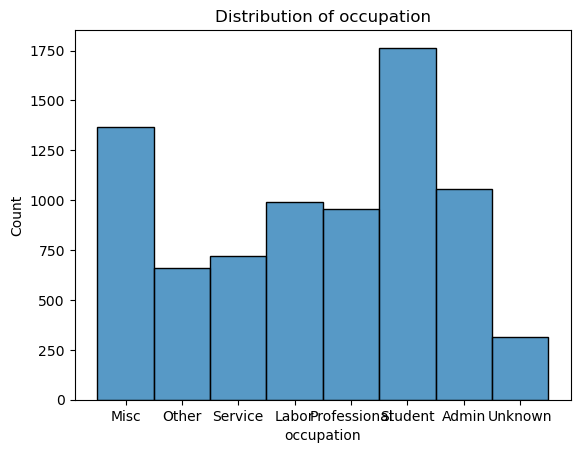

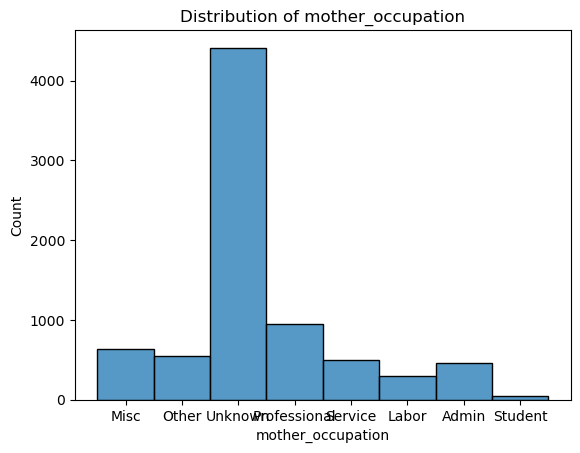

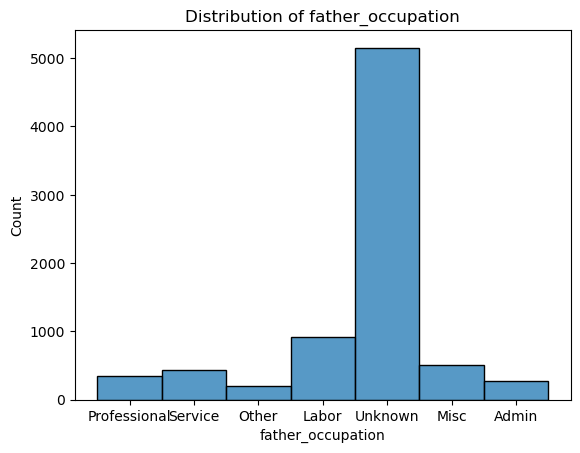

In [35]:
# plot distribution of each occupation column
occupation_cols = ["occupation", "mother_occupation", "father_occupation"]

for col in occupation_cols:
    sns.histplot(df[col], bins=20)
    plt.title(f"Distribution of {col}")
    plt.show()

Comment: It appears that the majority of the speakers are students, indicating a generally younger age range. The occupations for mother and father are mostly unknown (those who have passed away are listed as 'unknown' which may contribute to this large skew).

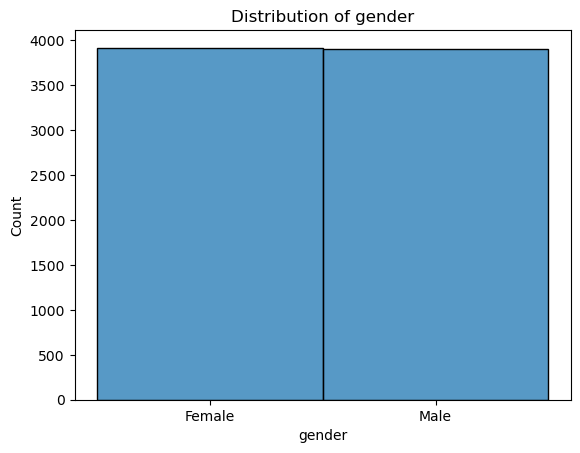

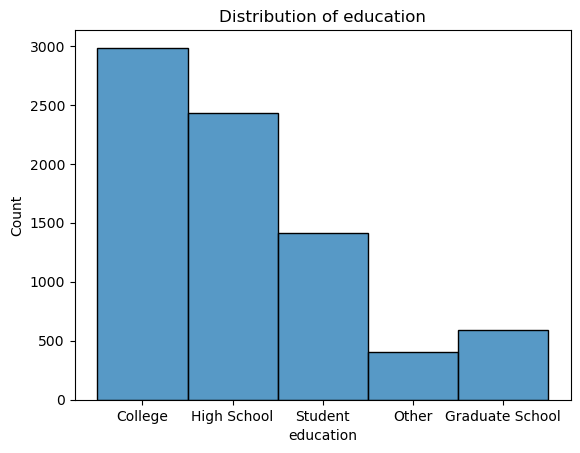

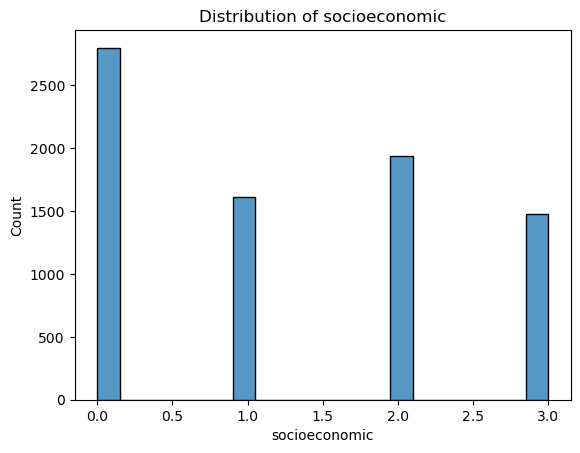

In [36]:
# view distribution of gender, education, socioeconomic
cols = ['gender', 'education', 'socioeconomic']
for col in cols:
    sns.histplot(df[col], bins=20)
    plt.title(f"Distribution of {col}")
    plt.show()

Note: 'socioeconomic' has been pre-encoded from the data source as the following:
- DCA:
    - Lower Working Class = 1
    - Upper Working Class = 2
    - Lower Middle Class = 3
    - Upper Middle Class = 3
    - Upper Class = 3
- DCB: 
    - Working Class = 1
    - Lower Middle Class = 2
    - Upper Middle Class = 3
- DTA: 
    - Lower Working Class = 1
    - Upper Working Class = 2
    - Lower Middle Class = 3
    - Upper Middle Class = 3
- The remaining regions (ATL, PRV, ROC, LES, and VLD) are all encoded as 0 (this data was not collected for these regions)
- The CORAAL creators note that these categories are rough estimates and group assignments are meant for balancing the corpus and as a heuristic. Please see CORAAL User Guide metadata notes for more information.
- For the purposes of this project, these encodings will be maintained and will not be restructured.

**Feature Encoding**

In [37]:
# one-hot encode 'gender' (binary variable)
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
ohe.fit(df[['gender']])
# add to dataset (new columns 'female' and 'male')
encoded = pd.DataFrame(
    ohe.transform(df[['gender']]).astype(int),
    index=df.index
).rename(columns={i: catg for i, catg in enumerate(ohe.categories_[0])})

df = pd.concat([df, encoded], axis=1)
df = df.drop(columns=["gender"]) # remove gender column

In [38]:
# one-hot encode occupation
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
ohe.fit(df[['occupation']])
encoded = pd.DataFrame(
    ohe.transform(df[['occupation']]).astype(int),
    index=df.index
).rename(columns={i: catg for i, catg in enumerate(ohe.categories_[0])})

df = pd.concat([df, encoded], axis=1)
df = df.drop(columns=["occupation"])

In [39]:
# one-hot encode 'mother_occupation'
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
ohe.fit(df[['mother_occupation']])
encoded = pd.DataFrame(
    ohe.transform(df[['mother_occupation']]).astype(int),
    index=df.index
).rename(columns={i: f'mother_{catg}' for i, catg in enumerate(ohe.categories_[0])})

df = pd.concat([df, encoded], axis=1)
df = df.drop(columns=["mother_occupation"])

In [40]:
# one-hot encode 'father_occupation'
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
ohe.fit(df[['father_occupation']])
encoded = pd.DataFrame(
    ohe.transform(df[['father_occupation']]).astype(int),
    index=df.index
).rename(columns={i: f'father_{catg}' for i, catg in enumerate(ohe.categories_[0])})

df = pd.concat([df, encoded], axis=1)
df = df.drop(columns=["father_occupation"])

In [41]:
# label encode education
le_education = LabelEncoder()

df["education"] = le_education.fit_transform(df["education"])

In [42]:
# viewing mapping of 'education'
mapping = dict(zip(le_education.classes_, range(len(le_education.classes_))))
print(mapping)

{'College': 0, 'Graduate School': 1, 'High School': 2, 'Other': 3, 'Student': 4}


Comment: Using Label Encoding for 'education' rather than one-hot because education is more of an ordinal scaled feature than previous features

In [43]:
# see all new columns after processing
df.columns

Index(['region', 'age', 'age_group', 'socioeconomic', 'education',
       'interview_year', 'year_of_birth', 'transcript', 'chunk_id',
       'chunk_word_count', 'Female', 'Male', 'Admin', 'Labor', 'Misc', 'Other',
       'Professional', 'Service', 'Student', 'Unknown', 'mother_Admin',
       'mother_Labor', 'mother_Misc', 'mother_Other', 'mother_Professional',
       'mother_Service', 'mother_Student', 'mother_Unknown', 'father_Admin',
       'father_Labor', 'father_Misc', 'father_Other', 'father_Professional',
       'father_Service', 'father_Unknown'],
      dtype='object')

In [44]:
df.dtypes

region                 object
age                     int64
age_group               int64
socioeconomic           int64
education               int64
interview_year          int64
year_of_birth           int64
transcript             object
chunk_id                int64
chunk_word_count        int64
Female                  int64
Male                    int64
Admin                   int64
Labor                   int64
Misc                    int64
Other                   int64
Professional            int64
Service                 int64
Student                 int64
Unknown                 int64
mother_Admin            int64
mother_Labor            int64
mother_Misc             int64
mother_Other            int64
mother_Professional     int64
mother_Service          int64
mother_Student          int64
mother_Unknown          int64
father_Admin            int64
father_Labor            int64
father_Misc             int64
father_Other            int64
father_Professional     int64
father_Ser

# Numerical Data Processing

In [45]:
# pull out numerical columns
num_cols = ["age", "interview_year", "chunk_word_count"]
df[num_cols] = df[num_cols].astype("int64")
df[num_cols]

,age,interview_year,chunk_word_count
0,32,2017,200
1,32,2017,200
2,32,2017,200
3,32,2017,200
4,32,2017,200
...,...,...,...
8059,57,2019,200
8060,57,2019,200
8061,57,2019,200
8062,57,2019,200


In [46]:
# check any missing data
df[num_cols].isna().sum()

age                 0
interview_year      0
chunk_word_count    0
dtype: int64

In [47]:
# viewing stats
df[num_cols].describe()

,age,interview_year,chunk_word_count
count,7826.000000,7826.000000,7826.000000
mean,35.800409,1998.475339,196.326093
std,18.686156,22.129921,21.283499
min,9.000000,1966.000000,1.000000
25%,23.000000,1968.000000,200.000000
50%,31.000000,2015.000000,200.000000
75%,48.000000,2016.000000,200.000000
max,84.000000,2019.000000,200.000000


In [48]:
# checking chunk word count
df["chunk_word_count"].value_counts().values

array([7532,    6,    6,    5,    4,    4,    4,    4,    4,    4,    4,
          4,    4,    4,    4,    3,    3,    3,    3,    3,    3,    3,
          3,    3,    3,    3,    3,    3,    3,    3,    3,    3,    3,
          3,    3,    3,    2,    2,    2,    2,    2,    2,    2,    2,
          2,    2,    2,    2,    2,    2,    2,    2,    2,    2,    2,
          2,    2,    2,    2,    2,    2,    2,    2,    2,    2,    2,
          2,    2,    2,    2,    2,    2,    2,    2,    2,    2,    2,
          2,    2,    2,    2,    2,    2,    2,    2,    2,    2,    2,
          2,    2,    2,    1,    1,    1,    1,    1,    1,    1,    1,
          1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
          1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
          1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
          1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
          1,    1,    1,    1,    1,    1,    1,   

Comment: Overwhelmingly, there are mostly chunks of 200 words long. Smaller chunks are likely too short to carry any meaningful information and will be removed.

In [49]:
# only keep chunks with 200 words
df = df[df["chunk_word_count"] == 200]

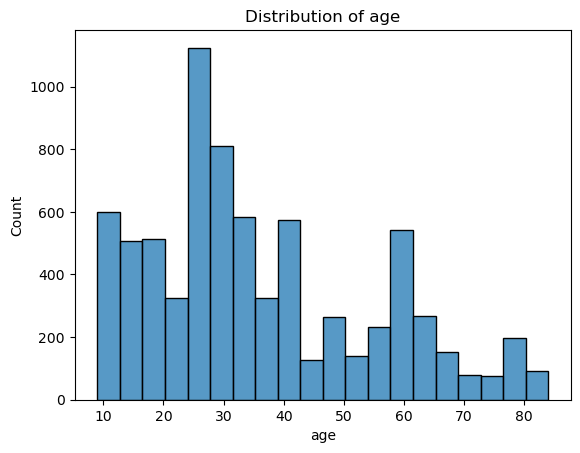

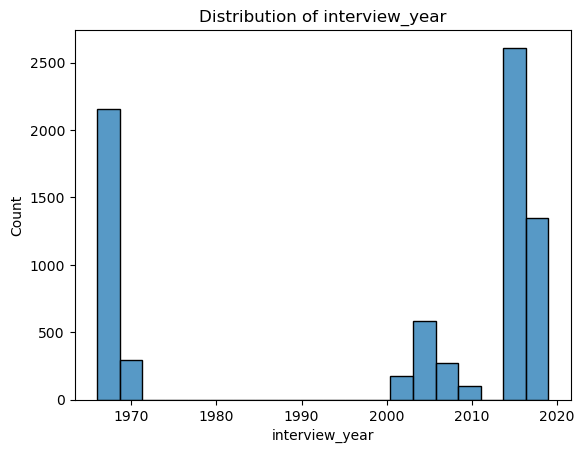

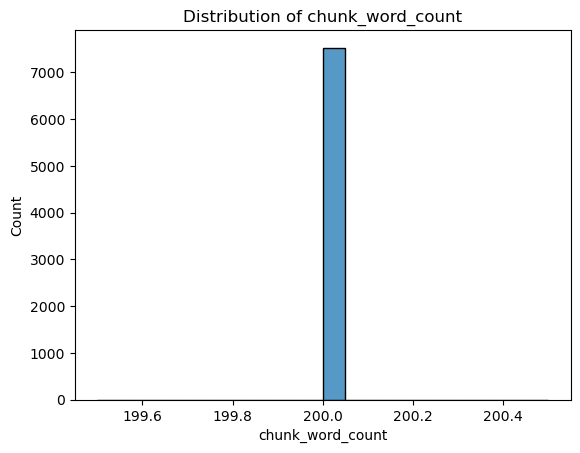

In [50]:
# distribution of each numerical column
for col in num_cols:
    sns.histplot(df[col], bins=20)
    plt.title(f"Distribution of {col}")
    plt.show()

Comment: No additional outliers, will keep all remaining data

**Creating the feature matrix X and the target y.** We will use a label encoder for y (assigning each region to an integer 0-7) and apply a TF-IDF vectorizer to the text data.

In [51]:
# label encode region
le = LabelEncoder()
y = le.fit_transform(df['region'])

# split first
train_idx, test_idx = train_test_split(
    np.arange(df.shape[0]),
    test_size=0.2,
    random_state=42,
    stratify=y
)

train_df = df.iloc[train_idx]
test_df = df.iloc[test_idx]

# drop target feature, transcript, and non-predictive columns to create feature matrix of just categorical data
drop_cols = ['region', 'chunk_id', 'chunk_word_count', 'transcript']
X_train_num = train_df.drop(columns=drop_cols)
X_test_num = test_df.drop(columns=drop_cols)

# TF-IDF
tfidf = TfidfVectorizer(
    max_features=10000,
    stop_words='english',
    ngram_range=(1,2),
    min_df=2
)
# create another feature matrix for text data separately
X_train_text = tfidf.fit_transform(train_df['transcript'])
X_test_text = tfidf.transform(test_df['transcript'])

# combine features (must be combined this way so that the text and numeric features align properly for the models)
X_train = hstack([X_train_text, X_train_num.values])
X_test = hstack([X_test_text, X_test_num.values])

y_train = le.transform(train_df['region'])
y_test = le.transform(test_df['region'])

In [52]:
# see mapping for each region after label encoding
region_mapping = dict(zip(le.classes_, range(len(le.classes_))))
print(region_mapping)

{'ATL': 0, 'DCA': 1, 'DCB': 2, 'DTA': 3, 'LES': 4, 'PRV': 5, 'ROC': 6, 'VLD': 7}


# Logistic Regression

In [53]:
# preliminary test (random parameters inputted)
lr_clf = LogisticRegression(max_iter=2000, solver='lbfgs', multi_class="auto", n_jobs=-1)
lr_clf.fit(X_train, y_train)
float("{:.3f}".format(lr_clf.score(X_test, y_test)))

/opt/anaconda3/envs/agents/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/envs/agents/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.792

In [54]:
# test with C = 2.0
lr_clf2 = LogisticRegression(max_iter=2000, C=2, n_jobs=-1)
lr_clf2.fit(X_train, y_train)
float("{:.3f}".format(lr_clf2.score(X_test, y_test)))

/opt/anaconda3/envs/agents/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.793

Comment: model performed slightly better with higher regularization tuning. Will check perfromance optimization with grid search.

In [55]:
# log reg grid search

# base model
log_reg = LogisticRegression(max_iter=2000)

# parameter grid to search
param_grid = {
    "C": [1, 2, 5],
    "solver": ["lbfgs", "saga"],
    "penalty": ["l2"],
    "multi_class": ["auto", "multinomial"]
}

# grid search
lr_model = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    cv=5,                 # 5-fold cross validation
    scoring="accuracy",   
    n_jobs=-1
)

lr_model.fit(X_train, y_train)

/opt/anaconda3/envs/agents/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/envs/agents/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/envs/agents/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/envs/agents/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1247: F

GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=2000), n_jobs=-1,
             param_grid={'C': [1, 2, 5], 'multi_class': ['auto', 'multinomial'],
                         'penalty': ['l2'], 'solver': ['lbfgs', 'saga']},
             scoring='accuracy')

In [56]:
# print best estimator from grid search and its score
print(lr_model.best_estimator_)
float("{:.3f}".format(lr_model.score(X_test, y_test)))

LogisticRegression(C=1, max_iter=2000, multi_class='auto')


0.792

Comment: slightly lower score than lr_clf2 (0.793), but more reliable with 5-fold cross validation. Will use as the final optimal Log Reg model.

In [57]:
y_pred_test_lr = lr_model.predict(X_test)
y_pred_test_lr

array([2, 6, 6, ..., 2, 2, 3], shape=(1507,))

In [58]:
y_predprob_test_lr = lr_model.predict_proba(X_test)
np.round(y_predprob_test_lr, 3)

array([[0.   , 0.   , 1.   , ..., 0.   , 0.   , 0.   ],
       [0.   , 0.   , 0.   , ..., 0.315, 0.421, 0.002],
       [0.   , 0.   , 0.   , ..., 0.033, 0.806, 0.001],
       ...,
       [0.   , 0.051, 0.823, ..., 0.   , 0.   , 0.   ],
       [0.   , 0.001, 0.998, ..., 0.   , 0.   , 0.   ],
       [0.   , 0.009, 0.   , ..., 0.   , 0.   , 0.   ]], shape=(1507, 8))

In [59]:
print(classification_report(y_test, y_pred_test_lr))

              precision    recall  f1-score   support

           0       0.75      0.70      0.72        66
           1       0.67      0.67      0.67       283
           2       0.93      0.90      0.92       478
           3       0.59      0.61      0.60       207
           4       0.71      0.77      0.74        74
           5       0.87      0.87      0.87       151
           6       0.83      0.89      0.86       167
           7       0.88      0.78      0.82        81

    accuracy                           0.79      1507
   macro avg       0.78      0.77      0.77      1507
weighted avg       0.79      0.79      0.79      1507



Comments: 

Overall, this model performs very well with a 0.79 weighted avg F1 score. It appears that precision and recall is quite high across almost all regions, though both seem to be lower for region 3 (DTA). Overall, these two metrics are similar with slightly different macro averages. This indicates that the model is good at predicting both true positives across all **predicted** positives and at predicting true positives across all **actual** positives.

**Top Features Analysis**

In [60]:
# get most important features
tfidf_features = tfidf.get_feature_names_out() # text features
other_features = X_train_num.columns.tolist() # categorical features
feature_names = list(tfidf_features) + other_features # combine for full features list

# create dataframe
coef_df = pd.DataFrame(
    lr_model.best_estimator_.coef_,
    columns=feature_names,
    index=le.classes_
)

In [61]:
# view top features for each region 
for region in coef_df.index:
    print(f"\nTop features for region: {region}")
    
    # sort coefficients descending
    top_features = coef_df.loc[region].sort_values(ascending=False).head(10)
    print("Top 10 positive features (predict this region):")
    print(top_features)


Top features for region: ATL
Top 10 positive features (predict this region):
Misc                   1.619391
mother_Professional    1.021266
father_Professional    0.714511
Male                   0.655793
mother_Misc            0.555788
father_Labor           0.291582
shit                   0.262263
father_Service         0.213440
Other                  0.147387
Service                0.144894
Name: ATL, dtype: float64

Top features for region: DCA
Top 10 positive features (predict this region):
socioeconomic          7.213727
education              3.142499
mother_Unknown         2.561781
father_Unknown         1.150278
Labor                  0.774711
Service                0.629671
Male                   0.529632
uh                     0.520842
father_Professional    0.490228
mmhm                   0.292953
Name: DCA, dtype: float64

Top features for region: DCB
Top 10 positive features (predict this region):
socioeconomic          6.503292
father_Service         2.016635
father_Mis

Comment: Interestingly, the model mostly relies on demographic data (socioeconomic status, occupation, etc.) rather than the text data. See below which text features are most important by isolating these features:

In [62]:
coef_df_tfidf = coef_df[tfidf_features] # pulling out only text features
for region in coef_df_tfidf.index:
    print(f"\nTop words for region: {region}")
    
    # top 10 positive words
    top_words = coef_df_tfidf.loc[region].sort_values(ascending=False).head(10)
    print("Top 10 words predicting this region:")
    print(top_words)


Top words for region: ATL
Top 10 words predicting this region:
shit           0.262263
man            0.135234
atlanta        0.126041
definitely     0.125461
saying         0.123930
know saying    0.117859
bruh           0.117647
cool           0.115473
feel           0.103900
nigga          0.103112
Name: ATL, dtype: float64

Top words for region: DCA
Top 10 words predicting this region:
education    3.142499
uh           0.520842
mmhm         0.292953
know         0.265994
teacher      0.226383
christmas    0.150177
group        0.144954
good         0.124173
play         0.118649
uh uh        0.117365
Name: DCA, dtype: float64

Top words for region: DCB
Top 10 words predicting this region:
education      1.339423
like           0.737925
dc             0.390911
cause          0.184000
know saying    0.183800
just           0.178587
saying         0.172223
like like      0.171994
just like      0.127952
sauce          0.125864
Name: DCB, dtype: float64

Top words for region: DTA
Top

Comment: These words are much more telling of how the model is training on the text data. Logically, it makes sense that words that relate to specific regions are important to the model ('atlanta', 'dc', 'detriot', 'brooklyn', etc.). Other important phrases ('know saying', 'know like', 'man', etc.) indicate local cultural markers (slang, community words). 

# Decision Tree Classifier

In [63]:
# preliminary test

X_train_dt = X_train.tocsr() # must convert to CSR format for dense matrix
X_test_dt = X_test.tocsr()

dt_clf = DecisionTreeClassifier(random_state=42)
dt_clf = dt_clf.fit(X_train_dt, y_train)
float("{:.3f}".format(dt_clf.score(X_test_dt, y_test)))

1.0

Comment: The model is definitely overfitting. Will view full tree model to see which features it splits on early.

In [64]:
# installing graphviz
os.environ["PATH"] += os.pathsep + "/opt/homebrew/bin"
!dot -V

dot - graphviz version 14.1.2 (20260124.0452)


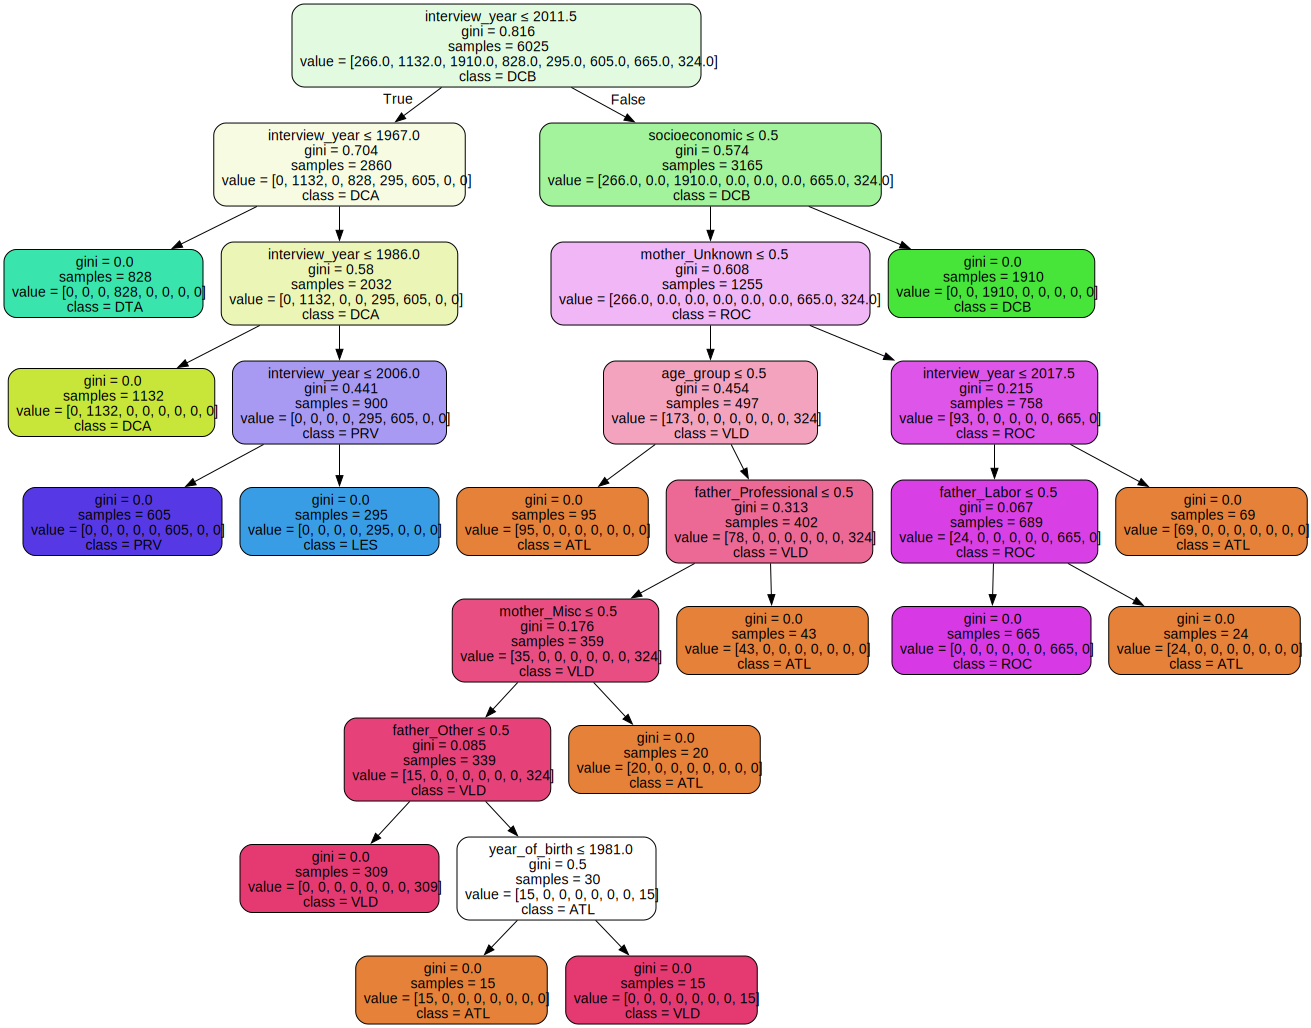

In [65]:
other_feature_names = X_train_num.columns.tolist()
feature_names = list(tfidf.get_feature_names_out()) + other_feature_names
class_names = le.classes_

dot_data = tree.export_graphviz(dt_clf, out_file=None,
                                feature_names=feature_names,
                                class_names=class_names,
                                filled=True,
                                rounded=True,
                                special_characters=True
                            )

graph = graphviz.Source(dot_data)
graph

Comment: Since the model is overfitting and appears to be splitting early on 'interview_year', this column will be removed as well as any duplicates in the test set.

In [66]:
# remove duplicates and 'interview_year' and refit model

from scipy.sparse import csr_matrix
import hashlib

drop_cols_new = ['region', 'chunk_id', 'chunk_word_count', 'transcript', 'interview_year']
X_train_num_new = train_df.drop(columns=drop_cols_new)
X_test_num_new = test_df.drop(columns=drop_cols_new)

# Combine numeric + text features
X_train_new = hstack([X_train_text, X_train_num_new.to_numpy()]).tocsr()
X_test_new = hstack([X_test_text, X_test_num_new.to_numpy()]).tocsr()

# Hash rows to remove duplicates from test set
def hash_sparse_row(row):
    row_csr = row.tocsr() if not isinstance(row, csr_matrix) else row
    return hashlib.md5(
        row_csr.data.tobytes() +
        row_csr.indices.tobytes() +
        row_csr.indptr.tobytes()
    ).hexdigest()

train_hashes = [hash_sparse_row(X_train_new[i]) for i in range(X_train_new.shape[0])]
test_hashes = [hash_sparse_row(X_test_new[i]) for i in range(X_test_new.shape[0])]

# Remove duplicate test rows
test_mask = [h not in set(train_hashes) for h in test_hashes]
keep_idx = np.where(test_mask)[0]
X_test_clean = X_test_new[keep_idx, :]
y_test_clean = y_test[keep_idx]

print("Number of test rows after removing duplicates:", X_test_clean.shape[0])

Number of test rows after removing duplicates: 1478


In [67]:
# re-run model without duplicates + add more hyperparameters to try to reduce overfitting

dt_clf_new = DecisionTreeClassifier(random_state=42, max_depth=10, min_samples_leaf=5, min_samples_split=10)
dt_clf_new = dt_clf_new.fit(X_train_new, y_train)
float("{:.3f}".format(dt_clf_new.score(X_test_clean, y_test_clean)))

0.966

Comment: Though better, this score is still quite and overfitting is still an issue. See new tree visualization to determine new early splits:

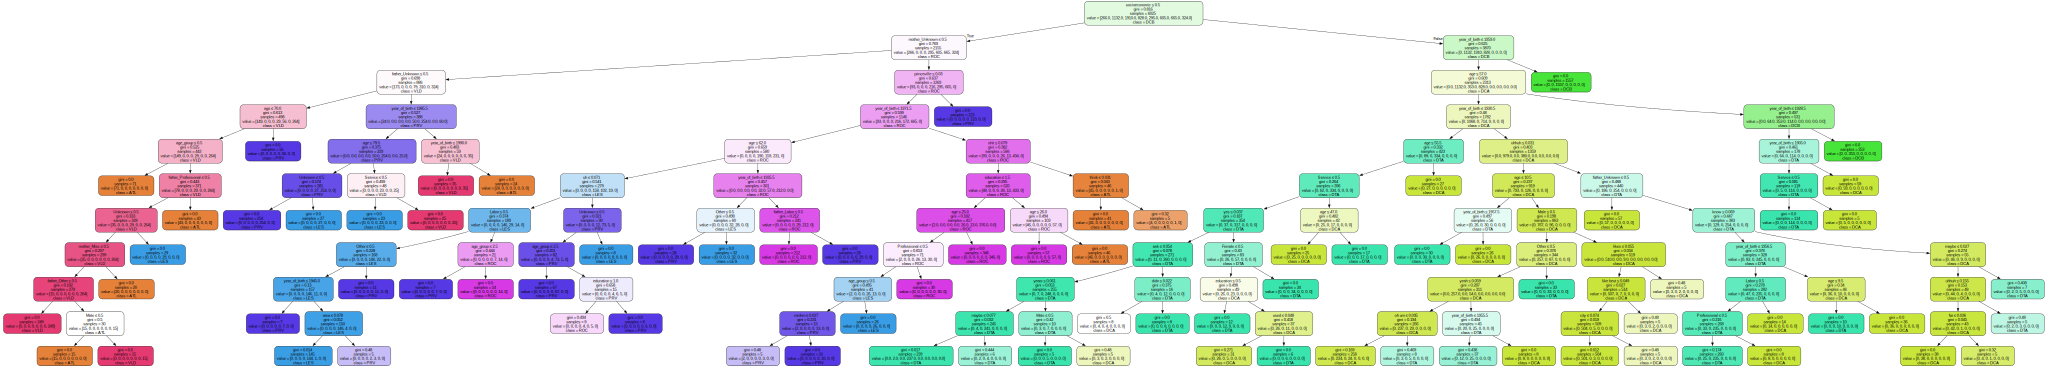

In [68]:
# visualize new tree
other_feature_names_new = X_train_num_new.columns.tolist()
feature_names_new = list(tfidf.get_feature_names_out()) + other_feature_names_new
dot_data_new = tree.export_graphviz(
    dt_clf_new,
    out_file=None,
    feature_names=feature_names_new,
    class_names=class_names,
    filled=True,
    rounded=True,
    special_characters=True
)
graph_new = graphviz.Source(dot_data_new)
graph_new

Comment: In its current state, the model continues to overfit no matter how the test data/parameters are tuned. This is expected because decision trees struggle for text analysis due to the dense text features. With so many features, it is easy for the tree to find splits that perfectly separate the training samples, leading to overfitting. In addition, decision trees are sensitive to noise in the text data; the tree can split on nonsense words, including typos, filler words, etc., which also can contribute to overfitting as these words do not contain any salient information. We will still keep the visuals, but will abandon further analysis with the Decision Tree altogether as this model is not well-suited for this type of data.

# Random Forest Classifier

In [69]:
# preliminary test
rf_clf = RandomForestClassifier(random_state=42, criterion = 'entropy', n_estimators=1000)
rf_clf = rf_clf.fit(X_train, y_train)
float("%.3f" % rf_clf.score(X_test,y_test))

0.973

Comment: Quite high score; model is likely overfitting.

In [70]:
# changing criterion
rf_clf = RandomForestClassifier(random_state=42, criterion = 'gini', n_estimators=1000)
rf_clf = rf_clf.fit(X_train, y_train)
float("%.3f" % rf_clf.score(X_test,y_test))

0.993

Comment: This score is even higher, so overfitting is definitely an issue using the preliminary parameters.

In [71]:
# limiting max_depth to reduce overfitting
rf_clf = RandomForestClassifier(random_state=42, max_depth=10, n_estimators=1000)
rf_clf = rf_clf.fit(X_train, y_train)
float("%.3f" % rf_clf.score(X_test,y_test))

0.737

Comment: Much better score; will use grid search to find optimal hyperparameters.

In [72]:
# grid search

# base model
rf_clf = RandomForestClassifier(random_state=42, criterion='entropy')

param_grid = {
    'n_estimators': [200, 500, 1000],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 5],
}

rf_model = GridSearchCV(
    estimator=rf_clf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

rf_model.fit(X_train, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   3.9s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   4.0s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   3.9s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   4.0s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   4.1s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=500; total time=  10.0s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=500; total time=  10.3s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=500; total time=  10.4s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=500; total time=  10.4s
[CV] END max_depth=10, min_sa

GridSearchCV(cv=5,
             estimator=RandomForestClassifier(criterion='entropy',
                                              random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [10, 20], 'min_samples_leaf': [1, 5],
                         'min_samples_split': [2, 5],
                         'n_estimators': [200, 500, 1000]},
             scoring='accuracy', verbose=2)

In [73]:
print(rf_model.best_estimator_)
float("{:.3f}".format(rf_model.score(X_test, y_test)))

RandomForestClassifier(criterion='entropy', max_depth=20, n_estimators=500,
                       random_state=42)


0.885

Comment: The model is performing very well; this score is high, but not >0.9 so overfitting is not as much of an issue with these parameters and cross-validation.

In [74]:
y_pred_test_rf = rf_model.predict(X_test)
y_pred_test_rf

array([2, 1, 6, ..., 2, 2, 3], shape=(1507,))

In [75]:
y_predprob_test_rf = rf_model.predict_proba(X_test)
np.round(y_predprob_test_rf, 3)

array([[0.031, 0.119, 0.71 , ..., 0.02 , 0.032, 0.036],
       [0.018, 0.193, 0.11 , ..., 0.142, 0.161, 0.03 ],
       [0.013, 0.135, 0.143, ..., 0.081, 0.301, 0.057],
       ...,
       [0.024, 0.089, 0.663, ..., 0.045, 0.067, 0.032],
       [0.051, 0.071, 0.621, ..., 0.048, 0.079, 0.067],
       [0.002, 0.212, 0.051, ..., 0.045, 0.032, 0.005]], shape=(1507, 8))

In [76]:
print(classification_report(y_test, y_pred_test_rf))

              precision    recall  f1-score   support

           0       1.00      0.39      0.57        66
           1       0.91      0.99      0.95       283
           2       0.79      1.00      0.88       478
           3       0.98      0.89      0.93       207
           4       1.00      0.59      0.75        74
           5       0.99      0.97      0.98       151
           6       0.92      0.94      0.93       167
           7       1.00      0.22      0.36        81

    accuracy                           0.89      1507
   macro avg       0.95      0.75      0.79      1507
weighted avg       0.90      0.89      0.87      1507



Comment: Similar to the logistic regression, the precision scores are high, but unlike the logreg, the recall scores are very different. The recall varies vastly from 0.22 to 1.00, showing that the model is overfitting for some regions, but performing badly for others. Interesting, region 7 (VLD) has a perfect precision, but a very low recall. This means the model has no false positives, but is only catching 22% of the actual samples in that region. This means the model is not confident for this region and is very conservative in its prediction (only predicts the region when it's 100% sure). In general, the model produces a good overall weighted average f1 score of 0.87.

**Top Features Analysis**

In [77]:
# get feature importances 

tfidf_features = tfidf.get_feature_names_out()
other_features = X_train_num.columns.tolist()  
feature_names_full = list(tfidf_features) + other_features

rf_importances = rf_model.best_estimator_.feature_importances_  

rf_df = pd.DataFrame({
    "feature": feature_names_full,
    "importance": rf_importances
}).sort_values("importance", ascending=False).reset_index(drop=True)

rf_df.head(20)

,feature,importance
0,interview_year,0.078489
1,socioeconomic,0.074938
2,year_of_birth,0.037036
3,mother_Unknown,0.036401
4,age,0.021943
5,education,0.020013
6,father_Unknown,0.017513
7,age_group,0.015708
8,uh,0.014937
9,mmhm,0.013501


Comments: Similar to the Logistic Regression, the Random Forest relies greatly on demographic features. Here, interview_year is most important which is somewhat logical given that some years are unqiue to certain regions. This could explain why the model was overfitting for some regions. Another interesting aspect is the prevalence of filler words/phrases like ('mmhm', 'uhhuh', 'uh', 'okay', etc) rather than geographic words like 'dc' and 'atlanta' like the logistic model. Though this model had a higher score, I am inclined to think that the logistic regression is more accurate and well-suited for the data due to its more understandable top features lists and the fact that the logistic regression did not show signs of overfitting. Overall, the random forest model performed better than the decision tree model, but worse than the logistic regression.

# Error Analysis

**Logistic Regression**

In [78]:
le.classes_

array(['ATL', 'DCA', 'DCB', 'DTA', 'LES', 'PRV', 'ROC', 'VLD'],
      dtype=object)

In [79]:
# see mismatched rows in dataset
errors = y_pred_test_lr != y_test # check logistic regression predictions
error_idx = np.where(errors)[0]

# create dataset of mismatches
lr_mismatches = test_df.iloc[error_idx].copy()
lr_mismatches['predicted_region'] = le.inverse_transform(y_pred_test_lr[error_idx])

# move 'region' to end so it's next to predicted_region
cols = [c for c in lr_mismatches.columns if c not in ["region", "predicted_region"]]
lr_mismatches = lr_mismatches[cols + ["region", "predicted_region"]]

lr_mismatches.head()

,age,age_group,socioeconomic,education,interview_year,year_of_birth,transcript,chunk_id,chunk_word_count,Female,...,mother_Unknown,father_Admin,father_Labor,father_Misc,father_Other,father_Professional,father_Service,father_Unknown,region,predicted_region
5750,76,3,0,2,2008,1932,"he you know, he's a motorcycle guy, as you. Ye...",32,200,0,...,1,0,0,0,0,0,0,1,LES,ROC
1054,24,1,2,2,1968,1944,"your parents. Hm, she kind of like and old wit...",18,200,0,...,1,0,0,0,0,0,0,1,DCA,DTA
847,17,0,2,4,1968,1951,"four on up, kids are advanced. They have littl...",13,200,1,...,1,0,0,0,0,0,0,1,DCA,DTA
1240,10,0,3,4,1968,1958,"they um, finally came back to a planet. Mmhm. ...",7,200,1,...,1,0,0,0,0,0,0,1,DCA,DTA
5021,9,0,3,4,1966,1957,"do like that? Like, little rhyme to say? Uh, y...",6,200,0,...,1,0,0,0,0,0,0,1,DTA,DCA


In [80]:
# how many mismatches
lr_mismatches.shape

(314, 36)

In [81]:
# inspect one mismatched line and transcript
print(textwrap.fill(lr_mismatches.loc[5750]['transcript'], width=100))
lr_mismatches.loc[[5750]]

he you know, he's a motorcycle guy, as you. Yeah. And he oh at the up north. Huh? He goes up north
right? Up the fr on the weekends? Yeah, but he doesn't go up there to ride a He goes up there for,
uh, he's got a farm up there. Mm. However, I mean, he used to ride all the time. He has so many
bikes. He had at least a half a dozen working bikes. Plus al uh, maybe another half a dozen to a
dozen bikes that weren't quite working. They all needed They all needed something. But the and he'd
fix bikes for people. He was a he's a expert uh, motorcycle mechanic. Where does he keep his bikes?
Well, they're all over the place now. He's got some up in West Chester. He used to have them in the
backyards and the basement, And the landlord, when he had to move man, he had to get all that stuff
out of there. Go to his sister's house, said yeah, she said no man, you got to get these bikes out
of here. So, He lived across the street from me on Sixth Street. Oh So,


,age,age_group,socioeconomic,education,interview_year,year_of_birth,transcript,chunk_id,chunk_word_count,Female,...,mother_Unknown,father_Admin,father_Labor,father_Misc,father_Other,father_Professional,father_Service,father_Unknown,region,predicted_region
5750,76,3,0,2,2008,1932,"he you know, he's a motorcycle guy, as you. Ye...",32,200,0,...,1,0,0,0,0,0,0,1,LES,ROC


Comment: In this mismatch, the true region is LES (Lower East Side) while the Logistic Regression model predicted ROC (Rochester); both areas within New York state. One reason why the model may have predicted incorrectly is the use of words in the transcript which may be more common to upstate or non-urban contexts (words/phrases like 'up north', 'farm', 'working bikes', 'mechanic', 'backyards', 'basement'). It is logical, given that these words do not indicate a large metropolis, that the model would be inclined to predict a more rural region. 

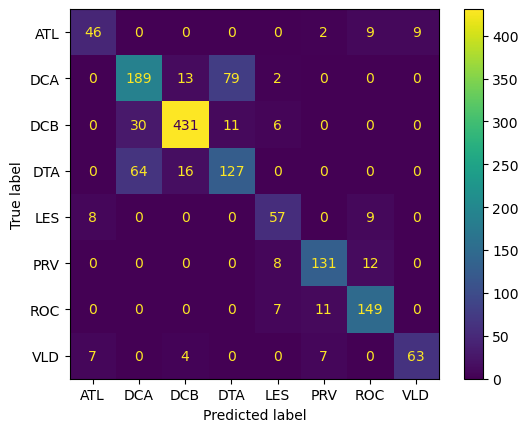

In [82]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred_test_lr, labels=lr_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot()

Interpretation: 

According to the matrix, the Logistic Regression model most accurately predicts the DCB region. Interestingly, it tends to confuse DCA (Washington, DC 1968-69) and DTA (Detriot 1966) for each other the most. While these two regions are geographically far from each other, it is logical for the model to mistake the two regions here because both regions include data from around the same points in time (and are the only two regions from this time frame). Given this matrix and the mismatch example, it seems that the model is picking up not only regional linguistic characteristics, but also differences in word choice (contextual information) and timeframe (language differences across time). This is also evidenced by the model's repeated confusion between DCA and DCB (Washington, DC 1968-69 vs 2015-16).

**Random Forest**

In [83]:
# check for where the model fails (Random Forest)

# see mismatched rows in dataset
errors = y_pred_test_rf != y_test # check random forest predictions
error_idx = np.where(errors)[0]

# create dataset of mismatches
rf_mismatches = test_df.iloc[error_idx].copy()
rf_mismatches['predicted_region'] = le.inverse_transform(y_pred_test_rf[error_idx])

# add all columns + new columns
# move 'region' to end so it's next to predicted_region
cols = [c for c in rf_mismatches.columns if c not in ['region', 'predicted_region']]
rf_mismatches = rf_mismatches[cols + ['region', 'predicted_region']]

rf_mismatches.head()

,age,age_group,socioeconomic,education,interview_year,year_of_birth,transcript,chunk_id,chunk_word_count,Female,...,mother_Unknown,father_Admin,father_Labor,father_Misc,father_Other,father_Professional,father_Service,father_Unknown,region,predicted_region
5750,76,3,0,2,2008,1932,"he you know, he's a motorcycle guy, as you. Ye...",32,200,0,...,1,0,0,0,0,0,0,1,LES,DCA
5431,29,1,0,0,2008,1979,"when they started doing stuff like that, I was...",17,200,1,...,0,0,0,0,0,0,0,1,LES,DCB
5566,38,2,0,2,2008,1970,"uh a all movies. Yeah. Or rent movies, and sho...",10,200,0,...,1,0,1,0,0,0,0,0,LES,DCB
7836,41,2,0,0,2017,1976,thirty you know what I'm saying. So we eased o...,16,200,0,...,0,0,1,0,0,0,0,0,VLD,DCB
7908,32,2,0,0,2018,1986,"real for real. But, It's crazy. So, why would ...",27,200,0,...,0,0,0,0,0,0,0,1,VLD,DCB


In [84]:
# how many mismatches
rf_mismatches.shape

(173, 36)

In [85]:
# inspect one line and transcript
print(textwrap.fill(rf_mismatches.loc[5431]['transcript'], width=100))
rf_mismatches.loc[[5431]]

when they started doing stuff like that, I was like, uhoh. And they came in hard to get the drug
dealers. Right? We well. Yeah, they did, but you know, they always leave a little bit of crack in
the in the ghetto. You know, you hafta appease the Right. was like a period where they were like,
this is now where we're gonna I mean. They neighborhood has changed so much to the point that the
hou the building that's right here on this corner, is now condominium lofts, I don't know. Is it
really? Yeah. Used to be the crack house. Like, you know what I mean? All these, all these buildings
along this street right here, this whole strip. Pitt Street actually was like dope fiend haven.
Forget crack. It was dope fiend haven. get any And it was like, you would see people leaning, like,
you know. To now, it's like tree lined and everything. You know what I'm saying now, the street is
actually, you can actually drive up the street without your car getting into Yeah. the deepest
pothole. So, it's unf

,age,age_group,socioeconomic,education,interview_year,year_of_birth,transcript,chunk_id,chunk_word_count,Female,...,mother_Unknown,father_Admin,father_Labor,father_Misc,father_Other,father_Professional,father_Service,father_Unknown,region,predicted_region
5431,29,1,0,0,2008,1979,"when they started doing stuff like that, I was...",17,200,1,...,0,0,0,0,0,0,0,1,LES,DCB


Comment: In this mismatch, the true region was LES (Lower East Side) while the Random Forest model predicted DCB (Washington, DC 2015-2016). Unlike the mismatch example from the Logistic Regression model, this mismatch is likely due to closeness in language and discussion themes rather than contextual differences in word choice. For example, this transcript contains dicussion of urban crimes and neighborhood transformation, including references to drug activity. These themes are common across multiple urban cities and this mismatch may be attributed to diffulties of the model to distinguish one major city from another. 

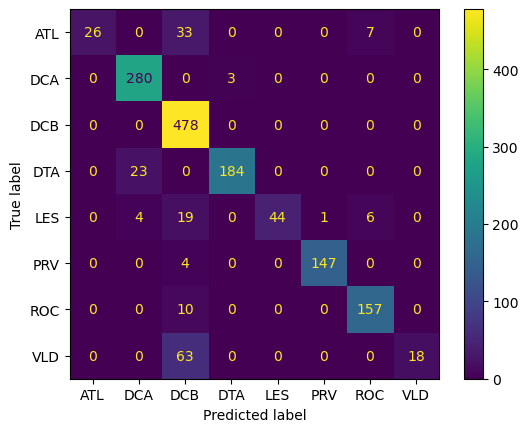

In [86]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred_test_rf, labels=rf_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot()

Commment: Again, the DCB region seems to be the easiest to distinguish. Unlike the Logistic Regression, this model does not seem to confuse DCA and DBA at all. It is interesting that this model predicts DCB for the VLD region more than its true region, but not the other way around. Both rf_mismatches and lr_mismatches appear to have some similar rows (samples which both models predicted incorrectly). rf_mismatches has far less rows overall than lr_mismatches (173 vs 314). See comparison between the two below:

In [87]:
shared_mismatches = lr_mismatches.index.intersection(rf_mismatches.index)
print("# of shared mismatches: ", len(shared_mismatches))

lr_only = lr_mismatches.index.difference(rf_mismatches.index)
print("# of LR only mismatches: ", len(lr_only))

rf_only = rf_mismatches.index.difference(lr_mismatches.index)
print("# of RF only mismatches: ", len(rf_only))

# of shared mismatches:  67
# of LR only mismatches:  247
# of RF only mismatches:  106


**Ensemble Learning**

In [88]:
from sklearn.ensemble import StackingClassifier

In [89]:
base_estimators = [(
    'rf', RandomForestClassifier(criterion='entropy', max_depth=20, min_samples_split=5,
                       n_estimators=1000, random_state=42)),
    ('lr', LogisticRegression(C=1, max_iter=2000, random_state=42, multi_class='auto')
)]

stack_clf = StackingClassifier(
    estimators=base_estimators,
    final_estimator=LogisticRegression(C=1, max_iter=2000, random_state=42, multi_class='auto'),
    cv=5,
    n_jobs=-1,
    passthrough=True
)

stack_clf.fit(X_train, y_train)
float("{:.3f}".format(stack_clf.score(X_test, y_test)))

/opt/anaconda3/envs/agents/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/envs/agents/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/anaconda3/envs/agents/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be remov

0.833

Interpretation: The Stacking Classifier acheived a score of 0.833 which reflects a combined decision strategy uisng both models. This score makes sense given the scores for the other models (LR = 0.792, RF = 0.885). This suggests that ensemble effectively integrates information from both models and reinforces the idea that regional linguistic features are detectable, but each model captures them in slightly different ways.

**Side Model: Text features alone**

Because the Unsupervised Model will be testing text data alone (without additional categorical features), we will explore the Supervised Models with just text data as well. This will allow for a more well-rounded analysis and a more direct approach to the main research ("How do patterns of language use among African American English (AAE) speakers reflect shared regional speech communities and which linguistic features are most indicative of regional differences?"). The same parameters will be used as above.

In [90]:
# linear reg 
lr_model.best_estimator_

LogisticRegression(C=1, max_iter=2000, multi_class='auto')

In [91]:
# Linear Regression (sm = side model)
X_sm = df['transcript']
y_sm = df['region']

X_train_sm, X_test_sm, y_train_sm, y_test_sm = train_test_split(X_sm, y_sm, test_size=0.2, random_state=42, stratify=y_sm)

X_train_sm_tfidf = tfidf.fit_transform(X_train_sm)
X_test_sm_tfidf = tfidf.transform(X_test_sm)

lr_model.best_estimator_.fit(X_train_sm_tfidf, y_train_sm) 
float("{:.3f}".format(lr_model.best_estimator_.score(X_test_sm_tfidf, y_test_sm)))

/opt/anaconda3/envs/agents/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


0.788

Comment: Here, the model performed very similarly (original score = 0.792) using just text data. This shows that there must be important indicators within the text that differentiates the regions enough that the model can pick up on it.

In [92]:
y_pred_test_lr_sm = lr_model.best_estimator_.predict(X_test_sm_tfidf)
y_pred_test_lr_sm

array(['DCB', 'PRV', 'DCA', ..., 'DCB', 'DCB', 'DTA'],
      shape=(1507,), dtype=object)

In [93]:
print(classification_report(y_test_sm, y_pred_test_lr_sm))

              precision    recall  f1-score   support

         ATL       0.97      0.56      0.71        66
         DCA       0.77      0.88      0.82       283
         DCB       0.71      0.97      0.82       478
         DTA       0.85      0.76      0.81       207
         LES       1.00      0.34      0.51        74
         PRV       0.95      0.82      0.88       151
         ROC       0.87      0.70      0.78       167
         VLD       1.00      0.16      0.28        81

    accuracy                           0.79      1507
   macro avg       0.89      0.65      0.70      1507
weighted avg       0.82      0.79      0.77      1507



Comment: Comparatively, the model maintains high precision, but the recall is much lower. Interestingly, we see a 1.00 precision and 0.16 recall for VLD, which were similar scores for the Random Forest model. This indicates that there is likely something within the texts that are strongly signaling 'VLD'. This same phenomenon is occurring with the 'LES' region, as well.

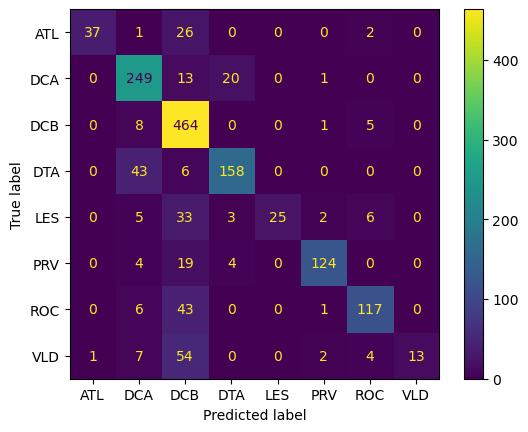

In [94]:
cm = confusion_matrix(y_test_sm, y_pred_test_lr_sm, labels=lr_model.best_estimator_.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=lr_model.best_estimator_.classes_)
disp.plot()

Comment: The DCB region consistently remains the most accurately predictive region, while VLD seems to be much more difficult to predict correctly.

In [95]:
feature_names = tfidf.get_feature_names_out()
for i, region in enumerate(lr_model.best_estimator_.classes_):
    coefs = lr_model.best_estimator_.coef_[i]
    top_features = np.argsort(coefs)[-10:][::-1]
    print(f"\nTop words for {region}")
    for feature in top_features:
        print(feature_names[feature], coefs[feature])


Top words for ATL
shit 4.449878578095614
definitely 3.4799043761637725
atlanta 3.4689995712304578
cool 3.1621809383338237
man 2.9503828151315097
type 2.5138749187208322
bruh 2.511865088499923
okay 2.425103698541685
nah 2.072291356527411
feel 2.0126321597532453

Top words for DCA
uh 3.75434688379459
mmhm 3.424616221264058
teacher 3.3860999690850435
know 2.934310232062033
group 2.517588889845795
christmas 2.4564208061383765
dog 2.278000139203495
good 2.0655628422099346
play 1.879290183966515
boy 1.8745649443528616

Top words for DCB
dc 6.013343707188241
like 3.685216479351117
neighborhood 2.344998651204648
cause 2.1852705797441483
southeast 2.1294545263924745
club 1.845492756034616
wanna 1.6247972280487635
chuck 1.579056832971374
know saying 1.5575683100937177
maryland 1.5435885897313335

Top words for DTA
uhhuh 6.744421677422067
mmhm 4.984015987941269
uh 4.477052614070775
detroit 2.9480162219445463
huh 2.2993458297841296
mmhm uh 2.1753550793006484
fight 2.158593753146786
says 1.8697162

Comment: Overall, the Logistic Regression results suggest that the model relies most greatly using a combination of explicit geographical references, conversational markers, and community slang words. Together, these patterns suggest that regional classification is driven not only by direct place references but also but subtle differences in conversational style.

**Random Forest**

In [96]:
# Random Forest 
rf_model.best_estimator_

RandomForestClassifier(criterion='entropy', max_depth=20, n_estimators=500,
                       random_state=42)

In [97]:
rf_model.best_estimator_.fit(X_train_sm_tfidf, y_train_sm) 
float("{:.3f}".format(rf_model.best_estimator_.score(X_test_sm_tfidf, y_test_sm)))

0.658

Comment: This result is much different from the original Random Forest model. This confirms that the model was relying too heavily on demographic/categorical data rather than the text features. It's clear that the model is struggling more using just text data, but overall still produces a somewhat good score.

In [98]:
y_pred_test_rf_sm = rf_model.best_estimator_.predict(X_test_sm_tfidf)
y_pred_test_rf_sm

array(['DCB', 'DCA', 'DCA', ..., 'DCB', 'DCB', 'DTA'],
      shape=(1507,), dtype=object)

In [99]:
print(classification_report(y_test_sm, y_pred_test_rf_sm))

              precision    recall  f1-score   support

         ATL       1.00      0.03      0.06        66
         DCA       0.67      0.75      0.71       283
         DCB       0.54      0.99      0.70       478
         DTA       0.88      0.50      0.64       207
         LES       1.00      0.22      0.36        74
         PRV       0.99      0.61      0.75       151
         ROC       1.00      0.54      0.71       167
         VLD       0.00      0.00      0.00        81

    accuracy                           0.66      1507
   macro avg       0.76      0.46      0.49      1507
weighted avg       0.72      0.66      0.62      1507



/opt/anaconda3/envs/agents/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/envs/agents/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/envs/agents/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Comment: Again, the precision is high, but we see a wide range of recall scores. The 'ATL' region is showing similar results as the earlier models with a 1.00 precision, but a very low recall score. The model is behaving very conservatively. Interestingly, it does not predict for 'VLD' at all, showing that it could not confidently detect any features in the text that indicate this region.

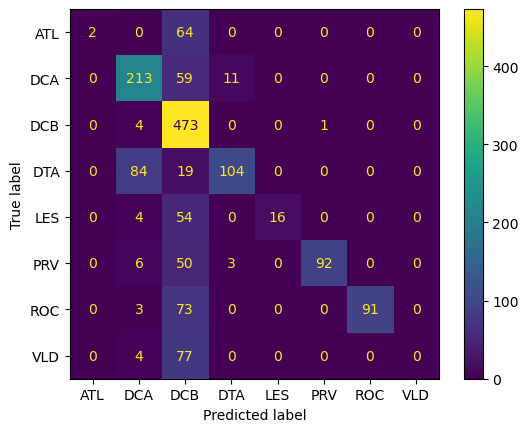

In [100]:
cm = confusion_matrix(y_test_sm, y_pred_test_rf_sm, labels=rf_model.best_estimator_.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf_model.best_estimator_.classes_)
disp.plot()

In [101]:
# get feature importances 

feature_names = tfidf.get_feature_names_out()
importances = rf_model.best_estimator_.feature_importances_

indices = np.argsort(importances)[-15:][::-1]
print("Top features")
for i in indices:
    print(feature_names[i], importances[i])    

Top features
mmhm 0.02160949719111114
like 0.01976309760050872
uh 0.018997725586831125
uhhuh 0.017949997480910158
yeah 0.016333696507793555
princeville 0.014878575630165395
okay 0.01334341463006972
dc 0.010395930276111664
know 0.009869772705148909
cause 0.009427523853675165
rochester 0.009253882815480232
mmhm uh 0.008753213375942717
wow 0.0074962062979271795
shit 0.007429366791269692
um 0.0070313034367360475


Comment: The Random Forest results show that the model relies primarily on common conversational markers and filler words. A small number of top importances refer to geographical places. Overall, the model captures subtle differences in speech and conversational behavior. Similar to the original Random Forest model, these results are not as easy to interpret as the Logistic Regression results given the prevalence of filler words.

# Unsupervised Model

Dimensionality Reduction (TruncatedSVD instead of PCA - Latent Semantic Analysis)
- designed for sparse TF-IDF matrices
- captures latent semantic structure
- common for NLP research
- use for visualization, detection regional separation, and preparation data for clustering

Clustering to detect emergent regional structure using K-Means
- standard baseline for text clustering
- compare clusters with regions

Topic Modelling (LDA)
- helps interpret what linguistic variation actually is
- examine top words per topic and topic distribution by region
    - reveals conversational themes
    - cultural context differences
    - discourse patterns

Liguistic Entropy
- lexical diversity
- distribution of words per region
- variation inside regions
    - high = linguistically diverse region
    - low = more uniform language


In [102]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
from sklearn.decomposition import PCA
from sklearn.decomposition import TruncatedSVD

In [103]:
df.head()

,region,age,age_group,socioeconomic,education,interview_year,year_of_birth,transcript,chunk_id,chunk_word_count,...,mother_Service,mother_Student,mother_Unknown,father_Admin,father_Labor,father_Misc,father_Other,father_Professional,father_Service,father_Unknown
0,ATL,32,2,0,0,2017,1984,Okay. How's it going? Of course my name is . I...,0,200,...,0,0,0,0,0,0,0,1,0,0
1,ATL,32,2,0,0,2017,1984,Georgia? Just for five years. Okay. Would you ...,1,200,...,0,0,0,0,0,0,0,1,0,0
2,ATL,32,2,0,0,2017,1984,"is where I get the Spaniards from. And um, Yea...",2,200,...,0,0,0,0,0,0,0,1,0,0
3,ATL,32,2,0,0,2017,1984,for cartoons and stuff like that. So there's a...,3,200,...,0,0,0,0,0,0,0,1,0,0
4,ATL,32,2,0,0,2017,1984,and I tell you about your mistakes. All while ...,4,200,...,0,0,0,0,0,0,0,1,0,0


Trying PCA first (though not suitable for dense data):

Explained variance: 0.018228406262676012
Ari:  0.09350062607216665


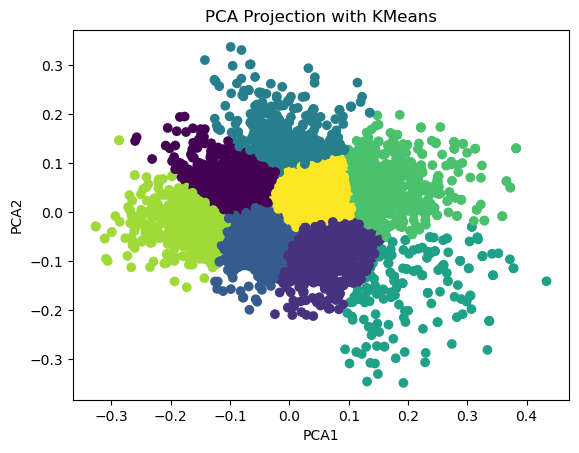

In [104]:
X_dense = X_train_text.toarray()

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_dense)
print("Explained variance:", pca.explained_variance_ratio_.sum())

kmeans = KMeans(n_clusters=len(le.classes_), random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_pca)

ari = adjusted_rand_score(y_train, clusters)
print("Ari: ", ari)

plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters)
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.title("PCA Projection with KMeans")
plt.show()

Comment: as expected, very low variance explained and low ARI. Move onto SVD:

In [105]:
# dimensionality reduction

# SVD with 100 components
svd = TruncatedSVD(n_components=100, random_state=42)

X_train_lsa = svd.fit_transform(X_train_text)
X_test_lsa = svd.transform(X_test_text)

print("Train shape:", X_train_lsa.shape)
print("Test shape:", X_test_lsa.shape)

Train shape: (6025, 100)
Test shape: (1507, 100)


In [106]:
# check variance explained (How much linguistic structure from the training data is captured in the latent semantic space)
explained_variance = svd.explained_variance_ratio_.sum()
print("Total explained variance:", round(explained_variance, 4))

Total explained variance: 0.197


Comment: still low, but better.

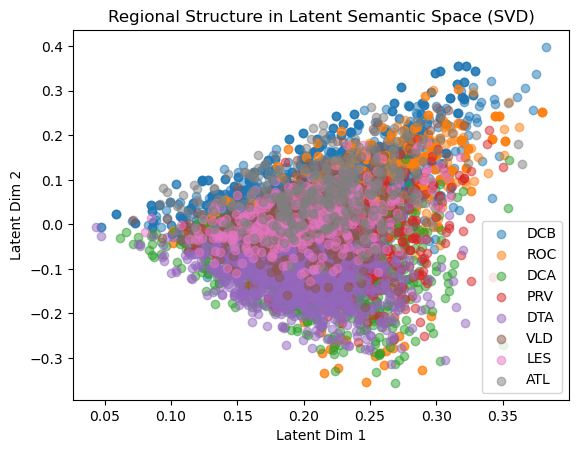

In [107]:
# visualization 
X_all_lsa = np.vstack([X_train_lsa, X_test_lsa])

region_all = pd.concat([train_df['region'], test_df['region']]).values

svd_df = pd.DataFrame({
    "SVD1": X_all_lsa[:, 0],
    "SVD2" : X_all_lsa[:, 1],
    "region": region_all
})

for region in svd_df['region'].unique():
    subset = svd_df[svd_df['region'] == region]
    plt.scatter(subset['SVD1'], subset['SVD2'], alpha=0.5, label=region)

plt.title("Regional Structure in Latent Semantic Space (SVD)")
plt.xlabel("Latent Dim 1")
plt.ylabel("Latent Dim 2")
plt.legend()
plt.show()

In the Latent Semantic Analysis using Truncated SVD, the latent dimensions represent the following:
- Latent Dim 1: the direction in the data that captures the largest amount of variance in word usage acorss all transcripts 
    - ex: might suggest urban neighborhood language vs rural/environmental language
- Latent Dim 2: the second largest independent pattern of variation in the data
    - ex: might suggest narrative storytelling vs. short conversational responses 
- ex: if a transcript point has coodindates (Latent Dim 1 = 1.8, Latent Dim 2 = -0.6), this means the transcript has a strong positive association with the first latent semantic pattern and a slightly negative association with the second semantic pattern

Plot Interpretation:
- The heavy overlap between the regions suggests that regional linguistic differences are relatively subtle compared to the overall variation in conversational language. This may mean that there are many shared linguistic features across regions or similarities in semantics/topic across regions. This result, along with the low ARI and explained variance indicates that regional linguistic patterns do not naturally separate into clear clusters in this dataset. 

KMeans visualization:

In [109]:
# K Means

region_all2 = pd.concat([
    train_df['region'],
    test_df['region']
]).reset_index(drop=True)

kmeans = KMeans(n_clusters=8, random_state=42, n_init=20)
clusters = kmeans.fit_predict(X_all_lsa)

clusters_df = pd.DataFrame({
    "region": region_all2,
    "cluster": clusters
})

In [110]:
pd.crosstab(clusters_df['cluster'], clusters_df['region'])

region,ATL,DCA,DCB,DTA,LES,PRV,ROC,VLD
cluster,,,,,,,,
0,62,15,678,3,38,45,268,54
1,2,185,24,113,3,2,0,7
2,2,185,18,95,2,5,0,8
3,22,86,210,47,19,52,62,77
4,61,565,517,441,120,491,112,146
5,84,62,721,34,180,92,314,85
6,98,1,179,0,4,0,14,23
7,1,316,41,302,3,69,62,5


In [111]:
ari = adjusted_rand_score(region_all2, clusters)
print("Adjusted Rand Index:", round(ari, 4))

Adjusted Rand Index: 0.0736


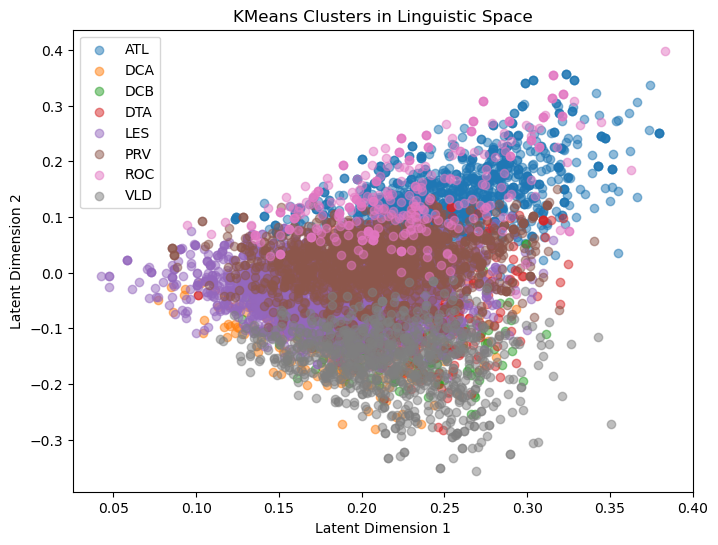

In [112]:
svd_vis = TruncatedSVD(n_components=2, random_state=42)
X_2d = svd_vis.fit_transform(X_all_lsa)

plot_df = pd.DataFrame({
    "SVD1": X_2d[:,0],
    "SVD2": X_2d[:,1],
    "region": region_all,
    "cluster": clusters
})

plt.figure(figsize=(8,6))

for c in sorted(plot_df["cluster"].unique()):
    subset = plot_df[plot_df["cluster"] == c]
    plt.scatter(subset["SVD1"], subset["SVD2"], alpha=0.5, label=le.inverse_transform([c])[0])

plt.title("KMeans Clusters in Linguistic Space")
plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")
plt.legend()
plt.show()

Interpretation: As expected given the results of the Latent Semantic Analysis, the KMeans Clustering also shows heavy overlap among the regions and returns a low ARI score of 0.0736. This suggests that the clustering barely aligns with the true regional labels and are almost random relative to actual regions. This may indicate that geography may have some influence over language, but not strongly enough for simple unsupervised methods to detect.

**Topic Modelling**

In [114]:
from gensim import corpora
from gensim.models import LdaModel, CoherenceModel
!pip install pyLDAvis
import pyLDAvis.gensim_models as gensimvis
import pyLDAvis


In [ ]:
from gensim.utils import simple_preprocess
from gensim.parsing.preprocessing import STOPWORDS

def preprocess(text): # removing extra whitespace and stopwords to help with tokenization
    tokens = simple_preprocess(text, deacc=True)
    tokens = [t for t in tokens if t not in STOPWORDS and len(t) > 3]
    return tokens

texts = df['transcript'].apply(preprocess)

dictionary = corpora.Dictionary(texts)
dictionary.filter_extremes(no_below=5, no_above=0.5, keep_n=10000)

corpus = [dictionary.doc2bow(text) for text in texts]

n_topics = 5 # started with 8 topics, reduced to 5 for better results

lda = LdaModel(corpus=corpus, id2word=dictionary, num_topics=n_topics, random_state=42, passes=20, alpha='auto', eta='auto')

topic_words = {}
for i, topic in lda.show_topics(num_topics=n_topics, formatted=False):
    topic_words[i] = [word for word, _ in topic]
    print(f"Topic {i}: " + ", ".join([word for word, _ in topic]))

coherence_model = CoherenceModel(model=lda, texts=texts, dictionary=dictionary, coherence='c_v')
coherence_lda = coherence_model.get_coherence()
print(f"\nLDA Coherence Score: {coherence_lda:.4f}")

lda_vis = pyLDAvis.gensim_models.prepare(lda, corpus, dictionary)
pyLDAvis.display(lda_vis)

Topic 0: people, think, cause, gonna, mean, good, wanna, things, right, time
Topic 1: okay, people, think, right, went, years, street, kind, cause, time
Topic 2: play, uhhuh, time, remember, kids, good, little, played, christmas, games
Topic 3: school, high, teacher, went, grade, class, think, year, college, okay
Topic 4: said, saying, gonna, cause, went, come, time, shit, house, came

LDA Coherence Score: 0.3417


Comment: The topics are quite distant from each other in general, with 1 and 2 overlapping somewhat. This means these topics share some words in common or semantic content.

In [ ]:
# create dataframe for topics by region

topic_words_df = pd.DataFrame(
    dict([(k, pd.Series(v)) for k,v in topic_words.items()]))

def get_dominant_topics(bow):
    topic_probs = lda.get_document_topics(bow)
    if topic_probs:
        return max(topic_probs, key=lambda x: x[1])[0]
    else:
        return None
    
dominant_topics = [get_dominant_topics(doc) for doc in corpus]
df_topics = df.copy()
df_topics['dominant_topic'] = dominant_topics

topic_region_counts= df_topics.groupby('region')['dominant_topic'].value_counts().unstack(fill_value=0)
print("\ntopic distribution by region:\n")
print(topic_region_counts)


topic distribution by region:

dominant_topic    0     1    2    3    4
region                                  
ATL             107    72   10   25  118
DCA             443   129  508  211  124
DCB             667  1013   95  233  380
DTA             282   124  447  130   52
LES              65   274   13   11    6
PRV             177   405   32   38  104
ROC             154   500   13  104   61
VLD             105   156   22   83   39


Comment: Given the consistent overlap in the clusters, it is logical that the topics are common across all regions.

In [117]:
# evaluate coherence of formed topics

def compute_topic_coherence(lda_model, processed_texts, diction, topn=10):
    topic_data = []
    for topic_id in range(lda_model.num_topics):
        words = [word for word, prob in lda_model.show_topic(topic_id, topn=topn)]
        cm = CoherenceModel(
            topics=[words],
            texts=processed_texts,
            dictionary=diction,
            coherence='c_v'
        )
        coherence = cm.get_coherence()
        topic_data.append({
            'topic': topic_id,
            'coherence': coherence,
            'top_words': ', '.join(words)
        })
    topic_df = pd.DataFrame(topic_data)
    
    return topic_df


In [118]:
topic_coherence_df = compute_topic_coherence(lda, texts, dictionary)
topic_coherence_df

,topic,coherence,top_words
0,0,0.348248,"people, think, cause, gonna, mean, good, wanna..."
1,1,0.330410,"okay, people, think, right, went, years, stree..."
2,2,0.489606,"play, uhhuh, time, remember, kids, good, littl..."
3,3,0.560830,"school, high, teacher, went, grade, class, thi..."
4,4,0.377283,"said, saying, gonna, cause, went, come, time, ..."


In [124]:
avg_coherence = np.mean(topic_coherence_df['coherence'])
avg_coherence

np.float64(0.42127545662125926)

Comment: The coherence for each topic is somewhat low to moderate meaning that the topics are somewhat meaningful, but the overlap in vocabulary/word patterns limits the coherences. Overall, the topics are not entirely distinct, as expected given the clusters.

**Entropy**

In [ ]:
# get topic probabilities for each document
doc_topics = []
for bow in corpus:
    topic_probs = lda.get_document_topics(bow, minimum_probability=0)
    probs = [prob for _, prob in topic_probs]
    doc_topics.append(probs)

doc_topics = np.array(doc_topics)

In [ ]:
from scipy.stats import entropy

# create dataframe for topic distributions to see entropy for each region
topic_cols = [f"topic_{i}" for i in range(lda.num_topics)]
topic_df = pd.DataFrame(doc_topics, columns=topic_cols)

entropy_df = pd.concat([df[['region']].reset_index(drop=True), topic_df], axis=1)
region_topic_dist = entropy_df.groupby('region')[topic_cols].mean()

region_entropy = region_topic_dist.apply(lambda x: entropy(x), axis=1)

region_entropy_df = region_entropy.reset_index()
region_entropy_df.columns = ['region', 'entropy']

In [122]:
region_entropy_df

,region,entropy
0,ATL,1.470213
1,DCA,1.512994
2,DCB,1.464408
3,DTA,1.458992
4,LES,1.213184
5,PRV,1.404775
6,ROC,1.315287
7,VLD,1.512335


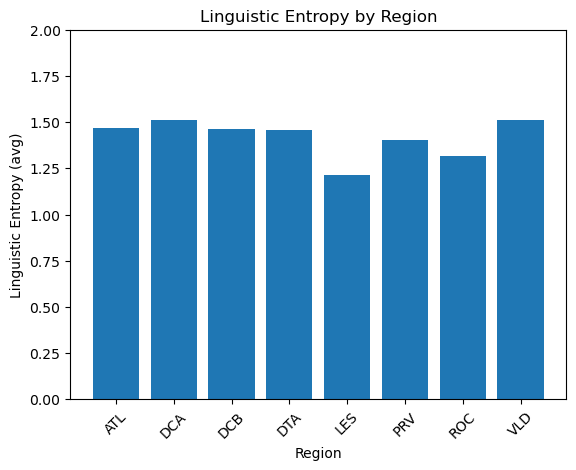

In [123]:
plt.figure()
plt.bar(region_entropy_df['region'], region_entropy_df['entropy'])
plt.xlabel('Region')
plt.ylabel('Linguistic Entropy (avg)')
plt.ylim(0,2)
plt.title('Linguistic Entropy by Region')
plt.xticks(rotation=45)
plt.show()

Comments: All relatively high (>1.2) meaning that all regions are linguistically diverse (given the split into 5 topics) and that each region uses most of the topics to some degree. While some regions may lean slightly more heavily on certain topics than others, no region is strongly dominated by a single topic, which is consistent with the overlap seen in the clustering analyses. It is interesting that the LES region has the lowest internal diversity, yet each supervised model struggled the most in predicting this region accurately.

## Conclusion

### Summary of Findings

1. **Supervised Learning:**

   * Logistic Regression and Random Forest models performed reasonably well on predicting region using all predictive features and from transcript data alone.
   * Random Forest achieved slightly higher accuracy than Logistic Regression, while Decision Trees were prone to overfitting.
   * Precision and recall varied greatly across regions: some regions like ATL were predicted with high precision but very low recall, indicating that the model can confidently identify a few region-specific cues but misses many other examples.
   * Feature analysis revealed that top predictive words were often location-specific proper nouns (“atlanta,” “dc,” “rochester,” “princeville”) and some discourse markers (“uh,” “mmhm,” “yeah”), highlighting that models rely both on lexical and conversational cues.

2. **Ensemble Learning:**

   * A stacking classifier combining Logistic Regression and Random Forest achieved accuracy ≈ 0.833, slightly below Random Forest alone (≈0.885).
   * This suggests that while ensembles can sometimes reduce variance and combine complementary strengths, in this dataset the marginal benefit is small because both base models capture similar regional signals, though these models rely on slightly different features for prediction.

3. **Unsupervised Learning:**

   * **LSA/SVD visualizations** showed heavy overlap of regions in latent space, indicating that transcript variation is not strongly separated by geography.
   * **KMeans clustering** produced clusters with low alignment to true regions (ARI ≈ 0.0736), further demonstrating that regional differences are subtle.
   * **LDA topic modeling** revealed moderate coherence (avg = 0.4212) and high entropy across regions (>1.2), meaning that each region discusses a wide range of topics, with no small set of topics dominating any region.

---

### Interpretation and Possible Explanations

* **Why supervised models worked better than unsupervised:**
  Supervised models can leverage subtle lexical and conversational cues that correlate with region, even if those cues are sparse. Unsupervised methods, however, try to find clusters or topic structures without any label guidance, and the diffuse nature of regional language signals makes it hard for them to separate regions naturally.

* **Why some regions are misclassified:**

  * Overlapping vocabulary across regions (e.g., generic conversation words like “uh,” “yeah”) dilutes distinctive regional markers.
  * Sparse data for underrepresented regions leads to lower recall.
  * Some misclassifications involve transcripts with content that does not include region-specific words, making predictions ambiguous.

* **High entropy in LDA:**
  Indicates that each region discusses many topics, so there is no dominant topical signature for any single region. This is consistent with the overlap seen in SVD and clustering.

---

### Pros and Cons of Each Model

| Model                   | Pros                                                                                                 | Cons                                                                                                  |
| ----------------------- | ---------------------------------------------------------------------------------------------------- | ----------------------------------------------------------------------------------------------------- |
| **Logistic Regression** | Interpretable coefficients; identifies important words; fast to train                                | May underfit complex patterns; limited nonlinear capacity                                             |
| **Decision Tree**       | Captures non-linear relationships; easy to visualize                                                 | Prone to overfitting; sensitive to sparse features; depends heavily on certain predictors (like year) |
| **Random Forest**       | Handles nonlinear patterns and sparse features; identifies important features | Less interpretable; may still miss rare regions; Prone to slight overfitting                            |
| **Stacking Ensemble**   | Combines strengths of multiple models; can reduce variance                                           | Marginal improvement if base models capture similar signals; more complexity                          |

---

### Possible Solutions to Improve Model Performance

1. **Feature Engineering:**

   * Focus on region-specific words or n-grams, possibly weighting proper nouns or geographic references more heavily.
   * Include phonetic or syntactic features from transcripts, which might capture subtler regional patterns.

2. **Data Balancing:**

   * Oversample or augment underrepresented regions to improve recall and overall fairness across regions.

3. **Other Vectorization/Embedding Methods:**

   * Explore contextual embeddings (e.g., BERT or Wav2Vec for audio) to capture deeper linguistic patterns.
   * Consider using CountVectorizer or Word2Vec to process text.

4. **Unsupervised Insights:**

   * Dimensionality reduction could be refined (more components, different algorithms like UMAP with a tuned neighborhood size).
   * Topic modeling could use domain-specific stop words or custom preprocessing to increase coherence.

---

### Combined Interpretation

* The results indicate that regional linguistic differences exist, but they are subtle, diffuse, and overlap across regions.
* Supervised models can detect these differences to some extent, particularly when distinctive words or phrases are present.
* Unsupervised approaches reveal that regions are not naturally separable in topic or latent semantic space, reflecting the complexity of spoken language.
* For underrepresented dialects, low recall or missing features highlights a broader issue in computational linguistics: models tend to favor common or high-resource dialects, making equitable modeling challenging.
